In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
from scipy import stats
import os
import platform
import warnings
import json
from datetime import datetime

# Windows fix for joblib
if platform.system() == 'Windows':
    os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (8, 6)
sns.set_style('whitegrid')

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, make_scorer,classification_report
)

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print(" Imports successful")
print(f" Windows fix: LOKY_MAX_CPU_COUNT={os.cpu_count()}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
print(f" Global random seed set: {RANDOM_SEED}")

 Imports successful
 Windows fix: LOKY_MAX_CPU_COUNT=12
 Global random seed set: 42


In [2]:
print(" LOADING UNSW-NB15 DATASET")

DATA_PATH  = Path(r"C:\Users\Sarika\Downloads\archive\UNSW-NB15_c")
TRAIN_FILE = "UNSW_NB15_training-set.csv"
TEST_FILE  = "UNSW_NB15_testing-set.csv"

def standardize_labels(df):
    for col in df.columns:
        if col.lower() in ('label', 'class', 'attack_cat'):
            if col != 'Label':
                df.rename(columns={col: 'Label'}, inplace=True)
            break
    if 'Label' in df.columns and not pd.api.types.is_numeric_dtype(df['Label']):
        df['Label'] = (df['Label'].astype(str).str.lower() != 'normal').astype(int)
    return df

def print_class_dist(df, name):
    n, a = (df['Label']==0).sum(), (df['Label']==1).sum()
    print(f" {name} — Normal: {n:,} ({n/len(df)*100:.1f}%)  Attack: {a:,} ({a/len(df)*100:.1f}%)")

try:
    train_df_clean = standardize_labels(pd.read_csv(DATA_PATH / TRAIN_FILE))
    test_df_clean  = standardize_labels(pd.read_csv(DATA_PATH / TEST_FILE))
    print_class_dist(train_df_clean, "CLEAN TRAIN")
    print_class_dist(test_df_clean,  "CLEAN TEST")
    train_df_faulty = train_df_clean.copy()
    test_df_faulty  = test_df_clean.copy()
    print(f" Train: {train_df_clean.shape} | Test: {test_df_clean.shape}")

except Exception as e:
    print(f" Error: {e} — generating synthetic fallback data")
    np.random.seed(RANDOM_SEED)
    n = 10000
    train_df_clean = pd.DataFrame({
        'dur': np.random.exponential(2, n),
        'proto': np.random.choice(['tcp','udp','icmp'], n),
        'service': np.random.choice(['http','dns','ftp','-'], n),
        'state': np.random.choice(['FIN','CON','INT'], n),
        'spkts': np.random.poisson(10, n), 'dpkts': np.random.poisson(8, n),
        'sbytes': np.random.poisson(1000, n), 'dbytes': np.random.poisson(800, n),
        'rate': np.random.exponential(20, n),
        'sttl': np.random.randint(32, 255, n), 'dttl': np.random.randint(32, 255, n),
        'sload': np.random.exponential(5000, n), 'dload': np.random.exponential(4000, n),
        'attack_cat': np.random.choice(['Normal','Fuzzers','DoS','Exploits'], n),
        'Label': np.random.choice([0,1], n, p=[0.45, 0.55])
    })
    test_df_clean   = train_df_clean.iloc[:2000].copy()
    train_df_faulty = train_df_clean.copy()
    test_df_faulty  = test_df_clean.copy()
    print(" Synthetic fallback data created")

 LOADING UNSW-NB15 DATASET
 CLEAN TRAIN — Normal: 37,000 (44.9%)  Attack: 45,332 (55.1%)
 CLEAN TEST — Normal: 56,000 (31.9%)  Attack: 119,341 (68.1%)
 Train: (82332, 45) | Test: (175341, 45)


In [3]:
print(" FEATURE ENGINEERING")

base_features = ['sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'spkts', 'dpkts', 'dur']

if 'sbytes' in train_df_clean.columns and 'dbytes' in train_df_clean.columns:
    train_df_clean['byte_ratio'] = train_df_clean['sbytes'] / (train_df_clean['dbytes'] + 1)
    train_df_faulty['byte_ratio'] = train_df_faulty['sbytes'] / (train_df_faulty['dbytes'] + 1)
    base_features.append('byte_ratio')
    print("   • Created byte_ratio")

if 'sttl' in train_df_clean.columns and 'dttl' in train_df_clean.columns:
    train_df_clean['ttl_diff'] = abs(train_df_clean['sttl'] - train_df_clean['dttl'])
    train_df_faulty['ttl_diff'] = abs(train_df_faulty['sttl'] - train_df_faulty['dttl'])
    base_features.append('ttl_diff')
    print("   • Created ttl_diff")

#categorical for supervised models
categorical_features = ['proto', 'service', 'state']
available_cats = [f for f in categorical_features if f in train_df_clean.columns]

final_features = base_features + available_cats
print(f"\n Total features: {len(final_features)}")

 FEATURE ENGINEERING
   • Created byte_ratio
   • Created ttl_diff

 Total features: 15


 INJECTING FAULTS 
 Injected 15% missing values
 Injected 8% outliers
 Flipped 12% labels
 Added 5% duplicates
 Added 20% sensor drift
 Injected Gaussian noise (std=10% of column std) across 6 columns

 Faulty dataset: 86,448 rows

 Visualizing fault injection impact


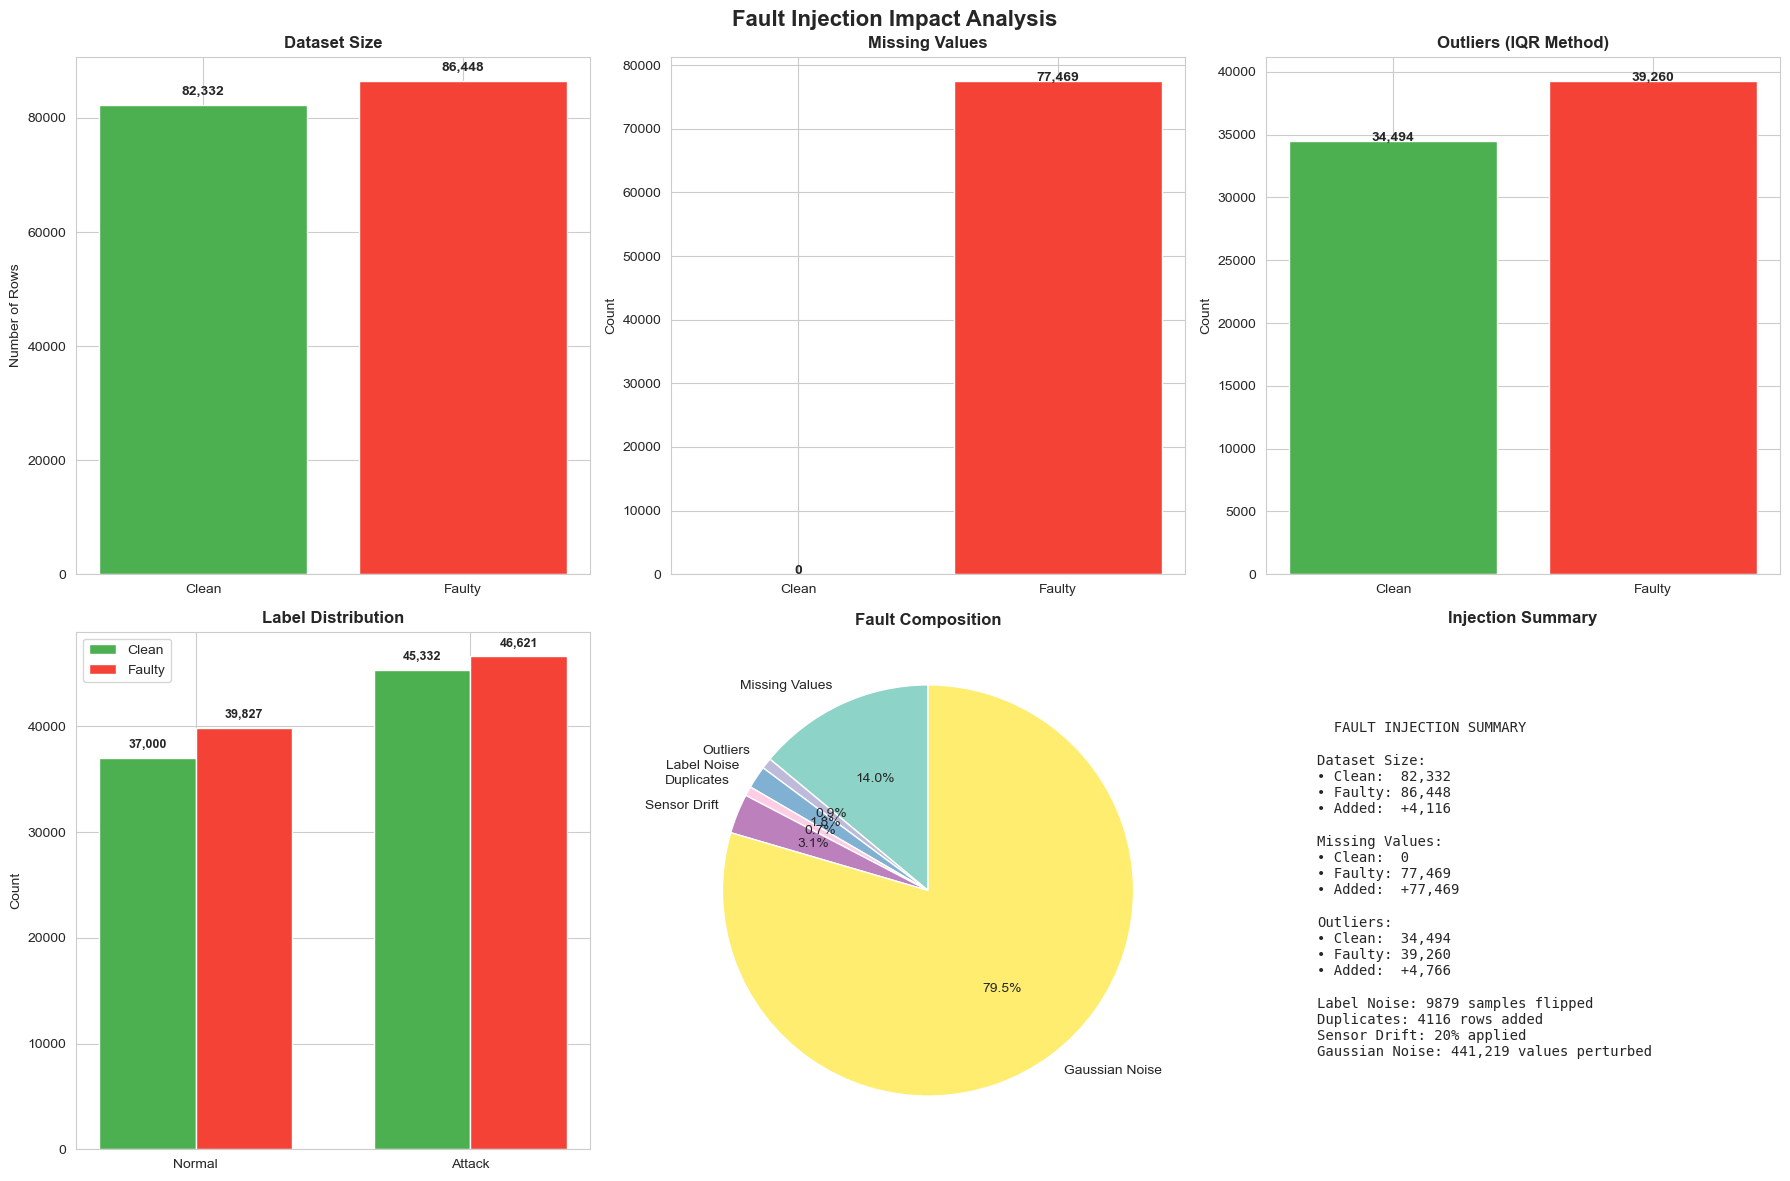

 Fault injection visualization saved as 'fault_injection_analysis.png'


In [4]:
#fault injection reproducibility
# Each fault is applied independently (not mutually exclusive), so a single row can carry more than one fault type. The test set (test_df_clean / test_df_faulty) is NOT modified here -
# only the training set is corrupted, matching the 'train on faulty, evaluate on real-world-like
# test data' framing used in the Results section.

print(" INJECTING FAULTS ")

fault_config = {
    'missing_values': {'enabled': True, 'rate': 0.15, 'columns': base_features[:6]},
    'outliers': {'enabled': True, 'rate': 0.08, 'columns': base_features[:6], 'multiplier': (20, 200)},
    'label_noise': {'enabled': True, 'rate': 0.12, 'flip_ratio': 0.5},
    'duplicates': {'enabled': True, 'rate': 0.05},
    'sensor_drift': {'enabled': True, 'drift': 0.20, 'columns': ['rate', 'sload', 'dload']},
    'gaussian_noise': {'enabled': True, 'std_fraction': 0.10, 'columns': base_features[:6]}
}

train_df_faulty = train_df_clean.copy()

fault_stats = {
    'missing_before': train_df_clean.isnull().sum().sum(),
    'outliers_before': 0,
    'label_noise_before': 0,
    'duplicates_before': train_df_clean.duplicated().sum(),
    'missing_after': 0,
    'outliers_after': 0,
    'label_noise_after': 0,
    'duplicates_after': 0,
    'rows_before': len(train_df_clean),
    'rows_after': len(train_df_clean),
    'gaussian_noise_after': 0
}

# outliers 
for col in base_features[:6]:
    if col in train_df_clean.columns:
        Q1 = train_df_clean[col].quantile(0.25)
        Q3 = train_df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((train_df_clean[col] < (Q1 - 1.5 * IQR)) | (train_df_clean[col] > (Q3 + 1.5 * IQR))).sum()
        fault_stats['outliers_before'] += outliers

#missing values
if fault_config['missing_values']['enabled']:
    rate = fault_config['missing_values']['rate']
    cols = fault_config['missing_values']['columns']
    for col in cols:
        if col in train_df_faulty.columns:
            mask = np.random.random(len(train_df_faulty)) < rate
            train_df_faulty.loc[mask, col] = np.nan
    print(f" Injected {rate*100:.0f}% missing values")

# Outliers
if fault_config['outliers']['enabled']:
    rate = fault_config['outliers']['rate']
    cols = fault_config['outliers']['columns']
    mult_min, mult_max = fault_config['outliers']['multiplier']
    for col in cols:
        if col in train_df_faulty.columns:
            valid = train_df_faulty[col].notna()
            n_outliers = int(valid.sum() * rate)
            if n_outliers > 0:
                idx = np.random.choice(train_df_faulty.index[valid], n_outliers, replace=False)
                mean_val = train_df_faulty[col].mean()
                train_df_faulty.loc[idx, col] = mean_val * np.random.uniform(mult_min, mult_max, n_outliers) * np.random.choice([1, -1], n_outliers)
    print(f" Injected {rate*100:.0f}% outliers")

# Label noise
if fault_config['label_noise']['enabled'] and 'Label' in train_df_faulty.columns:
    rate = fault_config['label_noise']['rate']
    n_mislabel = int(len(train_df_faulty) * rate)
    idx = np.random.choice(train_df_faulty.index, n_mislabel, replace=False)
    train_df_faulty.loc[idx, 'Label'] = 1 - train_df_faulty.loc[idx, 'Label']
    fault_stats['label_noise_after'] = n_mislabel
    print(f" Flipped {rate*100:.0f}% labels")

# Duplicates
if fault_config['duplicates']['enabled']:
    rate = fault_config['duplicates']['rate']
    n_dupes = int(len(train_df_faulty) * rate)
    if n_dupes > 0:
        dup_idx = np.random.choice(train_df_faulty.index, n_dupes, replace=True)
        dupes = train_df_faulty.loc[dup_idx].copy()
        train_df_faulty = pd.concat([train_df_faulty, dupes], ignore_index=True)
        fault_stats['duplicates_after'] = n_dupes
    print(f" Added {rate*100:.0f}% duplicates")

# Sensor drift
if fault_config['sensor_drift']['enabled']:
    drift = fault_config['sensor_drift']['drift']
    cols = fault_config['sensor_drift']['columns']
    for col in cols:
        if col in train_df_faulty.columns:
            drift_curve = 1 + drift * np.linspace(-1, 1, len(train_df_faulty))
            valid = train_df_faulty[col].notna()
            train_df_faulty.loc[valid, col] = train_df_faulty.loc[valid, col] * drift_curve[valid]
    print(f" Added {drift*100:.0f}% sensor drift")

# Gaussian noise
if fault_config['gaussian_noise']['enabled']:
    std_fraction = fault_config['gaussian_noise']['std_fraction']
    cols = fault_config['gaussian_noise']['columns']
    noisy_cells = 0
    for col in cols:
        if col in train_df_faulty.columns:
            valid = train_df_faulty[col].notna()
            col_std = train_df_faulty.loc[valid, col].std()
            noise = np.random.normal(0, std_fraction * col_std, size=valid.sum())
            train_df_faulty.loc[valid, col] = train_df_faulty.loc[valid, col] + noise
            noisy_cells += valid.sum()
    fault_stats['gaussian_noise_after'] = noisy_cells
    print(f" Injected Gaussian noise (std={std_fraction*100:.0f}% of column std) across {len(cols)} columns")

# Update statistics after faults
fault_stats['missing_after'] = train_df_faulty.isnull().sum().sum()
fault_stats['rows_after'] = len(train_df_faulty)

# Detect outliers after
for col in base_features[:6]:
    if col in train_df_faulty.columns:
        Q1 = train_df_faulty[col].quantile(0.25)
        Q3 = train_df_faulty[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((train_df_faulty[col] < (Q1 - 1.5 * IQR)) | (train_df_faulty[col] > (Q3 + 1.5 * IQR))).sum()
        fault_stats['outliers_after'] += outliers

print(f"\n Faulty dataset: {len(train_df_faulty):,} rows")


print("\n Visualizing fault injection impact")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Fault Injection Impact Analysis', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
bars = ax1.bar(['Clean', 'Faulty'], [fault_stats['rows_before'], fault_stats['rows_after']], 
               color=['#4CAF50', '#F44336'])
ax1.set_title('Dataset Size', fontweight='bold')
ax1.set_ylabel('Number of Rows')
for bar, val in zip(bars, [fault_stats['rows_before'], fault_stats['rows_after']]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 * max(bars[0].get_height(), bars[1].get_height()),
            f'{val:,}', ha='center', fontweight='bold')

# 2. Missing Values
ax2 = axes[0, 1]
bars = ax2.bar(['Clean', 'Faulty'], [fault_stats['missing_before'], fault_stats['missing_after']], 
               color=['#4CAF50', '#F44336'])
ax2.set_title('Missing Values', fontweight='bold')
ax2.set_ylabel('Count')
for bar, val in zip(bars, [fault_stats['missing_before'], fault_stats['missing_after']]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:,}', ha='center', fontweight='bold')

# 3. Outliers
ax3 = axes[0, 2]
bars = ax3.bar(['Clean', 'Faulty'], [fault_stats['outliers_before'], fault_stats['outliers_after']], 
               color=['#4CAF50', '#F44336'])
ax3.set_title('Outliers (IQR Method)', fontweight='bold')
ax3.set_ylabel('Count')
for bar, val in zip(bars, [fault_stats['outliers_before'], fault_stats['outliers_after']]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:,}', ha='center', fontweight='bold')

# 4. Label Distribution
ax4 = axes[1, 0]
if 'Label' in train_df_clean.columns and 'Label' in train_df_faulty.columns:
    clean_normal = (train_df_clean['Label'] == 0).sum()
    clean_attack = (train_df_clean['Label'] == 1).sum()
    faulty_normal = (train_df_faulty['Label'] == 0).sum()
    faulty_attack = (train_df_faulty['Label'] == 1).sum()
    
    x = np.arange(2)
    width = 0.35
    bars1 = ax4.bar(x - width/2, [clean_normal, clean_attack], width, label='Clean', color='#4CAF50')
    bars2 = ax4.bar(x + width/2, [faulty_normal, faulty_attack], width, label='Faulty', color='#F44336')
    ax4.set_title('Label Distribution', fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(['Normal', 'Attack'])
    ax4.set_ylabel('Count')
    ax4.legend()
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2, height + 0.02 * max(clean_normal, clean_attack, faulty_normal, faulty_attack),
                    f'{height:,}', ha='center', fontweight='bold', fontsize=9)

# 5. Fault Composition Pie Chart
ax5 = axes[1, 1]
fault_types = []
fault_counts = []

if fault_stats['missing_after'] - fault_stats['missing_before'] > 0:
    fault_types.append('Missing Values')
    fault_counts.append(fault_stats['missing_after'] - fault_stats['missing_before'])
if fault_stats['outliers_after'] - fault_stats['outliers_before'] > 0:
    fault_types.append('Outliers')
    fault_counts.append(fault_stats['outliers_after'] - fault_stats['outliers_before'])
if fault_stats['label_noise_after'] > 0:
    fault_types.append('Label Noise')
    fault_counts.append(fault_stats['label_noise_after'])
if fault_stats['duplicates_after'] > 0:
    fault_types.append('Duplicates')
    fault_counts.append(fault_stats['duplicates_after'])
if 'sensor_drift' in fault_config and fault_config['sensor_drift']['enabled']:
    fault_types.append('Sensor Drift')
    fault_counts.append(int(len(train_df_faulty) * fault_config['sensor_drift']['drift']))
if fault_stats.get('gaussian_noise_after', 0) > 0:
    fault_types.append('Gaussian Noise')
    fault_counts.append(fault_stats['gaussian_noise_after'])

if fault_counts:
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(fault_types)))
    ax5.pie(fault_counts, labels=fault_types, autopct='%1.1f%%', colors=colors_pie, startangle=90)
    ax5.set_title('Fault Composition', fontweight='bold')

ax6 = axes[1, 2]
ax6.axis('off')
summary_text = f"""
  FAULT INJECTION SUMMARY

Dataset Size:
• Clean:  {fault_stats['rows_before']:,}
• Faulty: {fault_stats['rows_after']:,}
• Added:  +{fault_stats['rows_after'] - fault_stats['rows_before']:,}

Missing Values:
• Clean:  {fault_stats['missing_before']:,}
• Faulty: {fault_stats['missing_after']:,}
• Added:  +{fault_stats['missing_after'] - fault_stats['missing_before']:,}

Outliers:
• Clean:  {fault_stats['outliers_before']:,}
• Faulty: {fault_stats['outliers_after']:,}
• Added:  +{fault_stats['outliers_after'] - fault_stats['outliers_before']:,}

Label Noise: {fault_stats['label_noise_after']} samples flipped
Duplicates: {fault_stats['duplicates_after']} rows added
Sensor Drift: {fault_config['sensor_drift']['drift']*100:.0f}% applied
Gaussian Noise: {fault_stats.get('gaussian_noise_after', 0):,} values perturbed
"""
ax6.text(0.1, 0.5, summary_text, fontsize=10, va='center', fontfamily='monospace')
ax6.set_title('Injection Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('fault_injection_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Fault injection visualization saved as 'fault_injection_analysis.png'")

 HYBRID FEATURE SELECTION
   TRAIN/TEST SPLIT FIRST
   Feature selection performed on TRAINING data ONLY

  Data split:
   • Training set: 65,865 samples
   • Test set:     16,467 samples

 Temporarily encoding 3 categorical columns
  Dropped leaking columns before selection: ['label', 'byte_ratio']
 Using 43 features for selection

 MANUAL SELECTION (Domain Knowledge)

   Feature groups:
   • critical: 11/11 features available
   • important: 9/9 features available
   • useful: 4/7 features available

 Manual selection: 16 features

 MUTUAL INFORMATION (on TRAIN only)

   Top 15 features by Mutual Information:
   • sbytes              : 0.4592
   • smean               : 0.3605
   • sload               : 0.3427
   • dbytes              : 0.2934
   • ct_state_ttl        : 0.2798
   • rate                : 0.2614
   • dur                 : 0.2515
   • dmean               : 0.2513
   • dttl                : 0.2433
   • dinpkt              : 0.2351
   • sttl                : 0.2187
   • dl

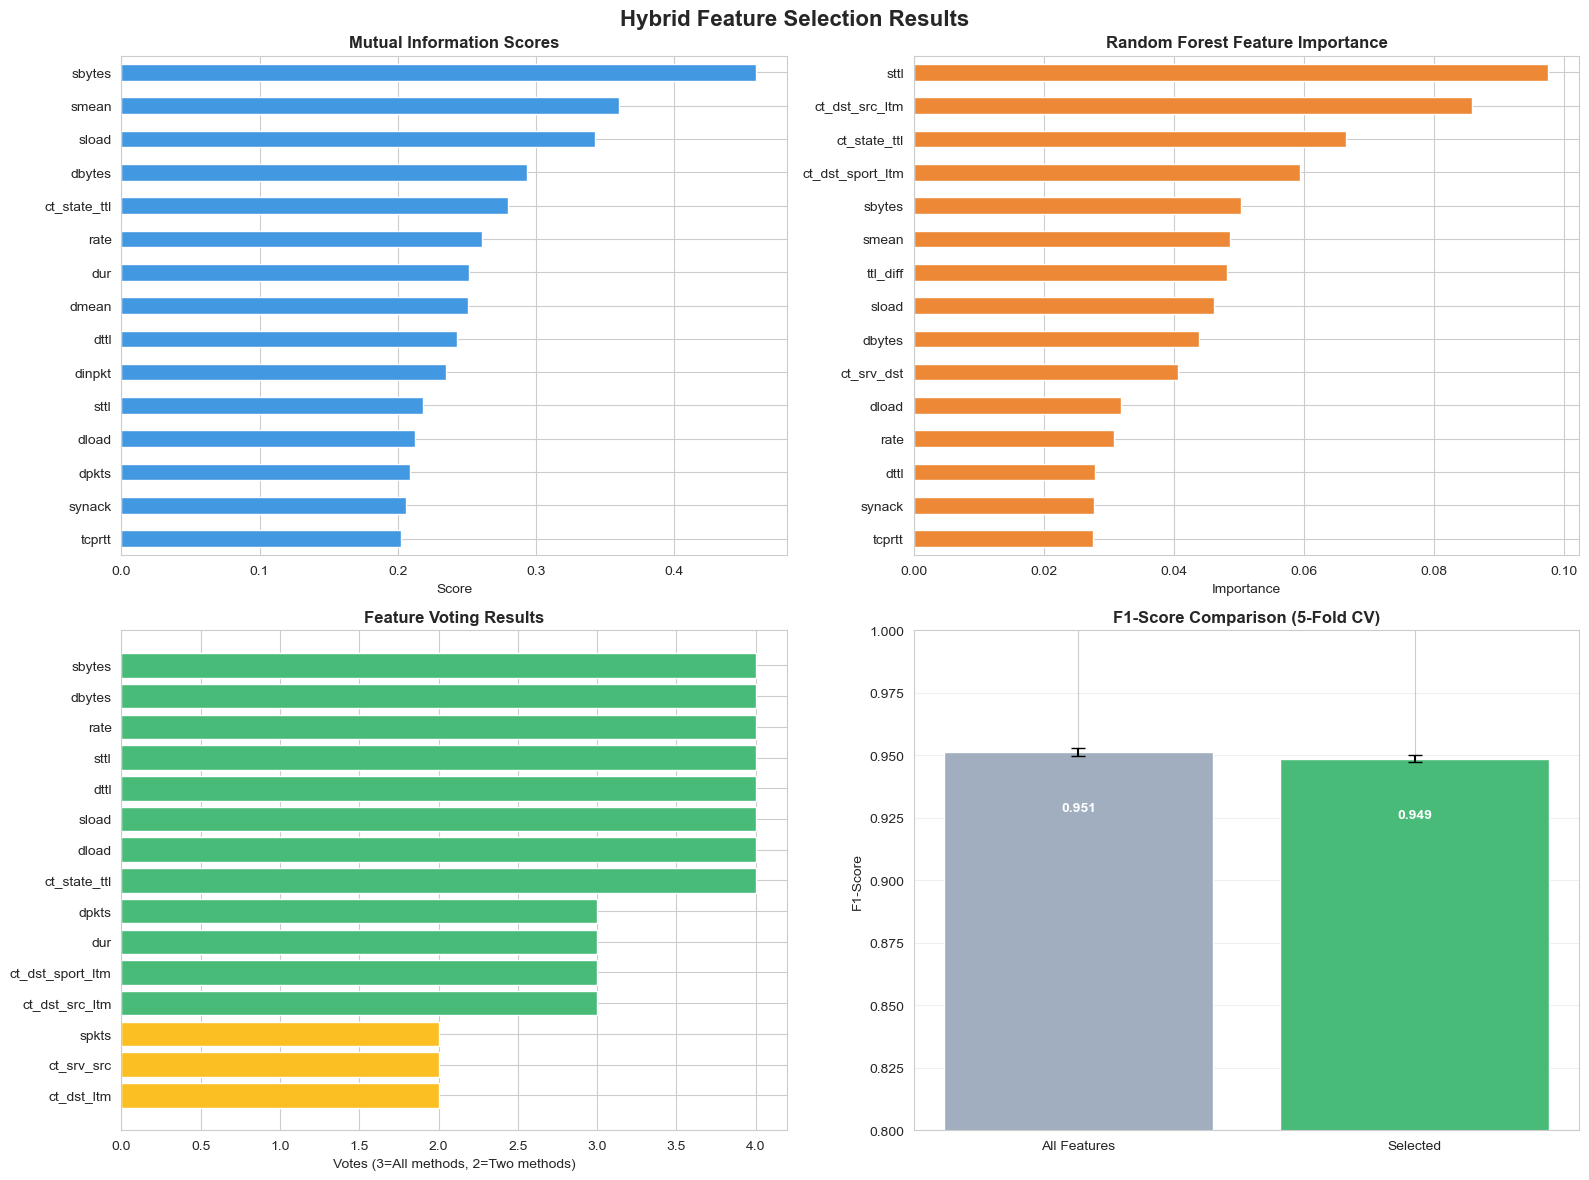

 Visualization saved as 'hybrid_feature_selection.png'

  Filtering datasets to selected features

  CLEAN data shapes:
   • Supervised: (82332, 16)
   • Anomaly:    (82332, 16)
 Feature sets saved to 'feature_sets.json'
 Filtered datasets saved (.pkl files)
 Metrics saved to 'feature_selection_metrics.json'

 Supervised features: 15
 Anomaly features:    15


In [5]:
print(" HYBRID FEATURE SELECTION")

X_full = train_df_clean.drop(['Label'], axis=1)
if 'attack_cat' in X_full.columns:
    X_full = X_full.drop(['attack_cat'], axis=1)
if 'id' in X_full.columns:
    X_full = X_full.drop(['id'], axis=1)
y_full = train_df_clean['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
print(f"\n  Data split:")
print(f"   • Training set: {X_train.shape[0]:,} samples")
print(f"   • Test set:     {X_test.shape[0]:,} samples")

categorical_cols   = X_train.select_dtypes(include=['object']).columns.tolist()
X_train_numeric    = X_train.copy()
if categorical_cols:
    print(f"\n Temporarily encoding {len(categorical_cols)} categorical columns")
    for col in categorical_cols:
        X_train_numeric[col] = pd.factorize(X_train_numeric[col])[0]

# Drop leaking columns 
cols_to_drop = ['label', 'Label', 'byte_ratio', 'attack_cat', 'id']
cols_to_drop = [c for c in cols_to_drop if c in X_train_numeric.columns]
if cols_to_drop:
    X_train_numeric = X_train_numeric.drop(cols_to_drop, axis=1)
    print(f"  Dropped leaking columns before selection: {cols_to_drop}")

print(f" Using {X_train_numeric.shape[1]} features for selection")

print("\n MANUAL SELECTION (Domain Knowledge)")
manual_features = {
    'critical':  ['sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload',
                  'spkts', 'dpkts', 'dur', 'ct_state_ttl'],
    'important': ['ct_srv_src', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
                  'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'swin', 'dwin'],
    'useful':    ['smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
                  'tcprtt', 'synack', 'ackdat']
}
print("\n   Feature groups:")
for group, features in manual_features.items():
    available = [f for f in features if f in X_train.columns]
    print(f"   • {group}: {len(available)}/{len(features)} features available")

manual_selected = manual_features['critical'] + manual_features['important'][:5]
manual_selected = [f for f in manual_selected if f in X_train.columns]
print(f"\n Manual selection: {len(manual_selected)} features")


print("\n MUTUAL INFORMATION (on TRAIN only)")
mi_selector = SelectKBest(mutual_info_classif, k='all')
mi_selector.fit(X_train_numeric, y_train)
mi_scores = pd.Series(
    mi_selector.scores_, index=X_train_numeric.columns
).sort_values(ascending=False)

print("\n   Top 15 features by Mutual Information:")
for feat, score in mi_scores.head(15).items():
    print(f"   • {feat:<20}: {score:.4f}")

mi_selected = mi_scores.head(15).index.tolist()
print(f"\n MI selection: {len(mi_selected)} features")


print("\n RANDOM FOREST IMPORTANCE (on TRAIN only)")
rf_selector = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
rf_selector.fit(X_train_numeric, y_train)
rf_importances = pd.Series(
    rf_selector.feature_importances_, index=X_train_numeric.columns
).sort_values(ascending=False)

print("\n   Top 15 features by Random Forest:")
for feat, score in rf_importances.head(15).items():
    print(f"   • {feat:<20}: {score:.4f}")

rf_selected_features = rf_importances.head(15).index.tolist()
print(f"\n RF selection: {len(rf_selected_features)} features")


print("\n  HYBRID VOTING")
feature_votes = {}
for feat in manual_selected:
    feature_votes[feat] = feature_votes.get(feat, 0) + 2
for feat in mi_selected:
    feature_votes[feat] = feature_votes.get(feat, 0) + 1
for feat in rf_selected_features:
    feature_votes[feat] = feature_votes.get(feat, 0) + 1

sorted_features = sorted(feature_votes.items(), key=lambda x: x[1], reverse=True)

print(f"\n   {'Feature':<20} {'Votes':<10} {'Manual':<8} {'MI':<8} {'RF':<8}")
print("   " + "-"*55)
for feat, votes in sorted_features[:20]:
    print(f"   {feat:<20} {votes:<10} "
          f"{'yes' if feat in manual_selected else 'no':<8}"
          f"{'yes' if feat in mi_selected else 'no':<8}"
          f"{'yes' if feat in rf_selected_features else 'no':<8}")

# Final feature selection
high_vote_features = [feat for feat, votes in sorted_features if votes >= 2]
if len(high_vote_features) > 18:
    final_selected = [feat for feat, _ in sorted_features[:15]]
else:
    final_selected = high_vote_features

print(f"\n FINAL SELECTED FEATURES (Supervised): {len(final_selected)}")
print(f"   {final_selected}")


print("\n CREATING ANOMALY FEATURE SET")
numeric_cols    = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
variances       = X_train[numeric_cols].var().sort_values(ascending=False)
anomaly_features = variances.head(15).index.tolist()
print(f"\n   Anomaly detection features ({len(anomaly_features)}):")
for feat in anomaly_features[:10]:
    print(f"   • {feat}")


print("\n VALIDATING SELECTION (Using F1-Score)")
f1_scorer  = make_scorer(f1_score)
cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_all     = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
scores_all_f1 = cross_val_score(rf_all, X_train_numeric, y_train, cv=cv, scoring=f1_scorer)
print(f"\n   ALL FEATURES ({X_train_numeric.shape[1]}):")
print(f"   • F1-Score: {scores_all_f1.mean():.4f} (+/- {scores_all_f1.std()*2:.4f})")

#validate features that exist in X_train_numeric
final_selected_valid = [f for f in final_selected if f in X_train_numeric.columns]
X_train_selected     = X_train_numeric[final_selected_valid]
rf_selected_model    = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
scores_sel_f1        = cross_val_score(rf_selected_model, X_train_selected, y_train, cv=cv, scoring=f1_scorer)
print(f"\n   SELECTED FEATURES ({len(final_selected_valid)}):")
print(f"   • F1-Score: {scores_sel_f1.mean():.4f} (+/- {scores_sel_f1.std()*2:.4f})")

f1_improvement = scores_sel_f1.mean() - scores_all_f1.mean()
print(f"\n   F1 Improvement: {f1_improvement:+.4f} ({f1_improvement*100:+.2f}%)")

# Visualisation
print("\n Visualizing feature selection...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hybrid Feature Selection Results', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
mi_scores.head(15).plot(kind='barh', ax=ax1, color='#4299e1')
ax1.set_title('Mutual Information Scores', fontweight='bold')
ax1.set_xlabel('Score')
ax1.invert_yaxis()

ax2 = axes[0, 1]
rf_importances.head(15).plot(kind='barh', ax=ax2, color='#ed8936')
ax2.set_title('Random Forest Feature Importance', fontweight='bold')
ax2.set_xlabel('Importance')
ax2.invert_yaxis()

ax3 = axes[1, 0]
vote_df = pd.DataFrame(sorted_features[:15], columns=['Feature', 'Votes'])
colors  = ['#48bb78' if v >= 3 else '#fbbf24' if v >= 2 else '#fc8181'
           for v in vote_df['Votes']]
ax3.barh(vote_df['Feature'], vote_df['Votes'], color=colors)
ax3.set_title('Feature Voting Results', fontweight='bold')
ax3.set_xlabel('Votes (3=All methods, 2=Two methods)')
ax3.invert_yaxis()

ax4 = axes[1, 1]
x    = ['All Features', 'Selected']
y    = [scores_all_f1.mean(), scores_sel_f1.mean()]
err  = [scores_all_f1.std(), scores_sel_f1.std()]
bars = ax4.bar(x, y, yerr=err, capsize=5, color=['#a0aec0', '#48bb78'])
ax4.set_title('F1-Score Comparison (5-Fold CV)', fontweight='bold')
ax4.set_ylabel('F1-Score')
ax4.set_ylim([0.8, 1.0])
for bar, val in zip(bars, y):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
             f'{val:.3f}', ha='center', va='top', fontweight='bold', color='white')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualization saved as 'hybrid_feature_selection.png'")


print("\n  Filtering datasets to selected features")
supervised_cols = final_selected + ['Label']
if 'attack_cat' in train_df_clean.columns:
    supervised_cols.append('attack_cat')
anomaly_cols = anomaly_features + ['Label']

train_df_clean_supervised  = train_df_clean[[c for c in supervised_cols if c in train_df_clean.columns]].copy()
test_df_clean_supervised   = test_df_clean[[c  for c in supervised_cols if c in test_df_clean.columns]].copy()
train_df_clean_anomaly     = train_df_clean[[c for c in anomaly_cols    if c in train_df_clean.columns]].copy()
test_df_clean_anomaly      = test_df_clean[[c  for c in anomaly_cols    if c in test_df_clean.columns]].copy()

train_df_faulty_supervised = train_df_faulty[[c for c in supervised_cols if c in train_df_faulty.columns]].copy() if train_df_faulty is not None else None
test_df_faulty_supervised  = test_df_faulty[[c  for c in supervised_cols if c in test_df_faulty.columns]].copy()  if test_df_faulty  is not None else None
train_df_faulty_anomaly    = train_df_faulty[[c for c in anomaly_cols    if c in train_df_faulty.columns]].copy() if train_df_faulty is not None else None
test_df_faulty_anomaly     = test_df_faulty[[c  for c in anomaly_cols    if c in test_df_faulty.columns]].copy()  if test_df_faulty  is not None else None

print(f"\n  CLEAN data shapes:")
print(f"   • Supervised: {train_df_clean_supervised.shape}")
print(f"   • Anomaly:    {train_df_clean_anomaly.shape}")


feature_sets = {
    'supervised_features': [str(f) for f in final_selected],
    'anomaly_features':    [str(f) for f in anomaly_features],
    'manual_selected':     [str(f) for f in manual_selected],
    'mi_selected':         [str(f) for f in mi_selected],
    'rf_selected':         [str(f) for f in rf_selected_features],
    'voting_results':      {str(k): int(v) for k, v in dict(sorted_features[:20]).items()}
}
with open('feature_sets.json', 'w') as f:
    json.dump(feature_sets, f, indent=2)

joblib.dump((train_df_clean_supervised,  test_df_clean_supervised),  'clean_data_supervised.pkl')
joblib.dump((train_df_clean_anomaly,     test_df_clean_anomaly),     'clean_data_anomaly.pkl')
if train_df_faulty_supervised is not None:
    joblib.dump((train_df_faulty_supervised, test_df_faulty_supervised), 'faulty_data_supervised.pkl')
    joblib.dump((train_df_faulty_anomaly,    test_df_faulty_anomaly),    'faulty_data_anomaly.pkl')

selection_metrics = {
    'all_features_f1':      float(scores_all_f1.mean()),
    'selected_features_f1': float(scores_sel_f1.mean()),
    'f1_improvement':       float(f1_improvement),
    'n_features_selected':  int(len(final_selected)),
    'n_features_anomaly':   int(len(anomaly_features))
}
with open('feature_selection_metrics.json', 'w') as f:
    json.dump(selection_metrics, f, indent=2)

print(" Feature sets saved to 'feature_sets.json'")
print(" Filtered datasets saved (.pkl files)")
print(" Metrics saved to 'feature_selection_metrics.json'")
print(f"\n Supervised features: {len(final_selected)}")
print(f" Anomaly features:    {len(anomaly_features)}")

In [6]:
# PREPROCESSING — SUPERVISED vs ANOMALY PIPELINES

print(" PREPROCESSING PIPELINES")
print(" RF/XGBoost : class_weight=balanced (no SMOTE)")
print(" Isolation Forest : normal samples only, no labels")

# Load feature-selected datasets

def load_pkl(path, name):
    try:
        data = joblib.load(path)
        print(f" {name} loaded")
        return data
    except:
        print(f" {name} not found")
        return None, None

train_clean_sup,  test_clean_sup  = load_pkl('clean_data_supervised.pkl',  'Clean supervised')
train_faulty_sup, test_faulty_sup = load_pkl('faulty_data_supervised.pkl', 'Faulty supervised')
train_clean_anom, test_clean_anom = load_pkl('clean_data_anomaly.pkl',     'Clean anomaly')
train_faulty_anom,test_faulty_anom= load_pkl('faulty_data_anomaly.pkl',    'Faulty anomaly')

# Supervised pipeline (RF, XGBoost) 
def prepare_supervised(train_df, test_df, name):
    if train_df is None or 'Label' not in train_df.columns:
        print(f" {name}: skipped"); return (None,)*6

    X_tr, y_tr = train_df.drop('Label', axis=1), train_df['Label']
    X_te, y_te = test_df.drop('Label', axis=1),  test_df['Label']

    num_cols = X_tr.select_dtypes(include=['int64','float64']).columns.tolist()
    cat_cols = X_tr.select_dtypes(include='object').columns.tolist()

    transformers = []
    if num_cols:
        transformers.append(('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler())]), num_cols))
    if cat_cols:
        transformers.append(('cat', Pipeline([
            ('imp', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols))

    pre = ColumnTransformer(transformers)
    X_tr_p = pre.fit_transform(X_tr)
    X_te_p = pre.transform(X_te)

    feat_names = num_cols + (
        list(pre.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols))
        if cat_cols else []
    )

    print(f" {name}: train {X_tr_p.shape}, test {X_te_p.shape} | "
          f"Normal {(y_tr==0).sum():,}  Attack {(y_tr==1).sum():,}")
    return X_tr_p, X_te_p, y_tr, y_te, pre, feat_names

X_tr_cl,  X_te_cl,  y_tr_cl,  y_te_cl,  pre_cl,  fn_cl  = prepare_supervised(train_clean_sup,  test_clean_sup,  "CLEAN")
X_tr_fa,  X_te_fa,  y_tr_fa,  y_te_fa,  pre_fa,  fn_fa  = prepare_supervised(train_faulty_sup, test_faulty_sup, "FAULTY")

#Anomaly pipeline (Isolation Forest normal only)

def prepare_anomaly(train_df, test_df, name):
    if train_df is None or 'Label' not in train_df.columns:
        print(f" {name}: skipped"); return (None,)*6

    X_tr, y_tr = train_df.drop('Label', axis=1), train_df['Label']
    X_te, y_te = test_df.drop('Label', axis=1),  test_df['Label']

    common = [c for c in X_tr.select_dtypes(include=['int64','float64']).columns
              if c in X_te.columns]

    imp = SimpleImputer(strategy='median')
    sc  = MinMaxScaler()
    X_tr_s = sc.fit_transform(imp.fit_transform(X_tr[common]))
    X_te_s = sc.transform(imp.transform(X_te[common]))

    X_tr_normal = X_tr_s[(y_tr == 0).values]
    print(f" {name}: training on {len(X_tr_normal):,} normal samples / {len(y_tr):,} total")
    return X_tr_normal, X_te_s, y_te, sc, imp, common

X_an_cl, X_te_an_cl, y_te_an_cl, sc_cl, imp_cl, nc_cl = prepare_anomaly(train_clean_anom,  test_clean_anom,  "CLEAN anomaly")
X_an_fa, X_te_an_fa, y_te_an_fa, sc_fa, imp_fa, nc_fa = prepare_anomaly(train_faulty_anom, test_faulty_anom, "FAULTY anomaly")

def save(obj, path): joblib.dump(obj, path)

if X_tr_cl  is not None: save((X_tr_cl,  y_tr_cl),  'clean_supervised_train.pkl');  save((X_te_cl,  y_te_cl),  'clean_supervised_test.pkl');  save(pre_cl, 'clean_supervised_preprocessor.pkl')
if X_tr_fa  is not None: save((X_tr_fa,  y_tr_fa),  'faulty_supervised_train.pkl'); save((X_te_fa,  y_te_fa),  'faulty_supervised_test.pkl'); save(pre_fa, 'faulty_supervised_preprocessor.pkl')
if X_an_cl  is not None: save((X_an_cl,  None),     'clean_anomaly_train.pkl');     save((X_te_an_cl, y_te_an_cl), 'clean_anomaly_test.pkl');  save(sc_cl, 'clean_anomaly_scaler.pkl');  save(imp_cl, 'clean_anomaly_imputer.pkl')
if X_an_fa  is not None: save((X_an_fa,  None),     'faulty_anomaly_train.pkl');    save((X_te_an_fa, y_te_an_fa),'faulty_anomaly_test.pkl'); save(sc_fa, 'faulty_anomaly_scaler.pkl'); save(imp_fa, 'faulty_anomaly_imputer.pkl')

feat_info = {k: [str(f) for f in v] for k, v in [
    ('supervised_clean',  fn_cl or []), ('supervised_faulty', fn_fa or []),
    ('anomaly_clean',     nc_cl or []), ('anomaly_faulty',    nc_fa or [])
] if v}
if feat_info:
    with open('preprocessing_feature_info.json', 'w') as f: json.dump(feat_info, f, indent=2)

print("\n Preprocessing done — class_weight handles imbalance in RF/XGBoost")

 PREPROCESSING PIPELINES
 RF/XGBoost : class_weight=balanced (no SMOTE, mild 55/45 imbalance)
 Isolation Forest : normal samples only, no labels
 Clean supervised loaded
 Faulty supervised loaded
 Clean anomaly loaded
 Faulty anomaly loaded
 CLEAN: train (82332, 15), test (175341, 15) | Normal 37,000  Attack 45,332
 FAULTY: train (86448, 15), test (175341, 15) | Normal 39,827  Attack 46,621
 CLEAN anomaly: training on 37,000 normal samples / 82,332 total
 FAULTY anomaly: training on 39,827 normal samples / 86,448 total

 Preprocessing done — class_weight handles imbalance in RF/XGBoost


 ISOLATION FOREST - DATA QUALITY AUDITOR
Unsupervised anomaly detection - trained ONLY on normal samples
NO SMOTE applied
Separate pipelines for CLEAN vs FAULTY

 Loading preprocessed anomaly data
 CLEAN anomaly data loaded successfully
 FAULTY anomaly data loaded successfully

 DATA AVAILABILITY SUMMARY:

 CLEAN data:
   • Train (normal only): 37,000 samples, 14 features
   • Test: 175,341 samples
   • Test class distribution: Normal: 56,000, Attack: 119,341
   • Attack rate: 68.1% (but attacks are NOT anomalies!)

    Using fixed contamination = 0.01 (1% expected anomalies)

 FAULTY data:
   • Train (normal only): 39,827 samples, 14 features
   • Test: 175,341 samples
   • Test class distribution: Normal: 56,000, Attack: 119,341
   • Attack rate: 68.1%

    Using fixed contamination = 0.01 (1% expected anomalies)
 TRAINING ON CLEAN NORMAL DATA

 Training Isolation Forest on CLEAN normal data...
 Training completed in 2.11 seconds
   • Trained on 37000 normal samples
   • Contaminatio

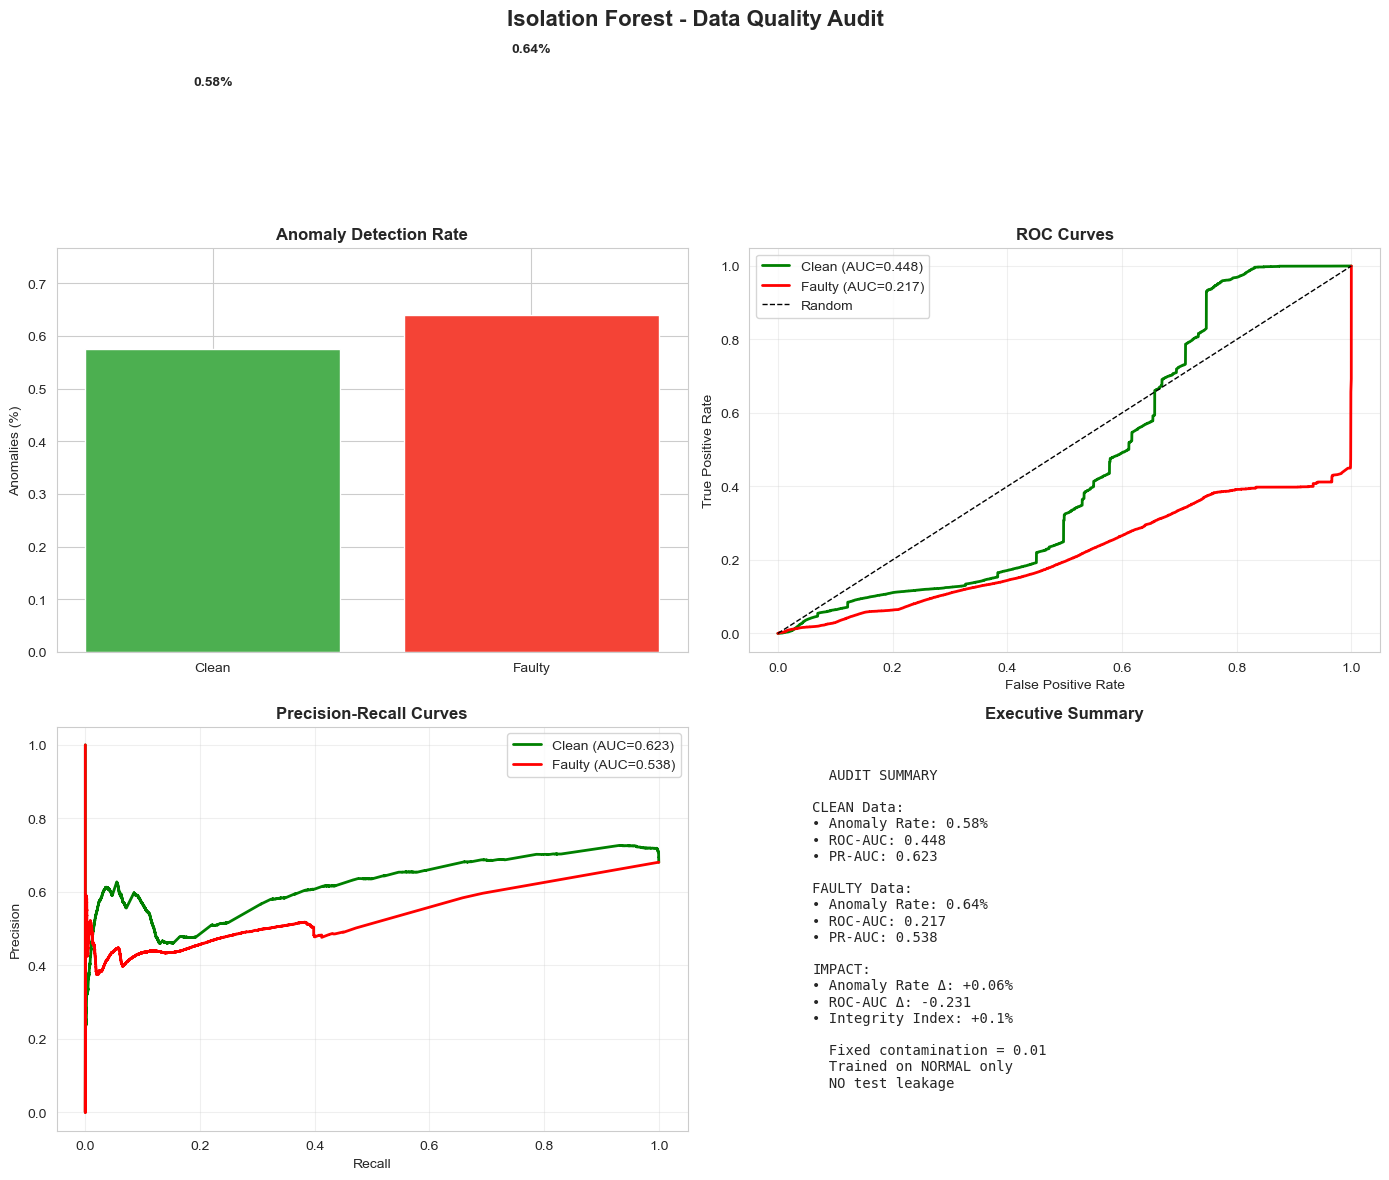

 Audit visualization saved as 'isolation_forest_audit.png'
 Isolation Forest Audit Done


In [15]:
print(" ISOLATION FOREST - DATA QUALITY AUDITOR")
print("Unsupervised anomaly detection - trained ONLY on normal samples")

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc

# Load preprocessed anomaly data
print("\n Loading preprocessed anomaly data")

X_train_clean = None
X_test_clean = None
y_test_clean = None
X_train_faulty = None
X_test_faulty = None
y_test_faulty = None

# loading CLEAN data
try:
    X_train_clean, _ = joblib.load('clean_anomaly_train.pkl')
    X_test_clean, y_test_clean = joblib.load('clean_anomaly_test.pkl')
    print(" CLEAN anomaly data loaded successfully")
except FileNotFoundError:
    print(" CLEAN anomaly data files not found")
except Exception as e:
    print(f" Error loading CLEAN anomaly data: {e}")

# loading FAULTY data
try:
    X_train_faulty, _ = joblib.load('faulty_anomaly_train.pkl')
    X_test_faulty, y_test_faulty = joblib.load('faulty_anomaly_test.pkl')
    print(" FAULTY anomaly data loaded successfully")
except FileNotFoundError:
    print(" FAULTY anomaly data files not found")
except Exception as e:
    print(f" Error loading FAULTY anomaly data: {e}")

# Check if we have at least one dataset to work with
if X_train_clean is None and X_train_faulty is None:
    print("\n No anomaly data files found! Cannot proceed.")
    print("   Please run CELL 8 first to generate the preprocessed data.")
    raise FileNotFoundError("No anomaly data files found")


# Fixed contamination - anomalies should be rare (1-5% of data) For UNSW-NB15, attacks are NOT anomalies in the dataset structure
# So we set very low contamination to detect TRUE statistical outliers
FIXED_CONTAMINATION = 0.01  # Only 1% expected anomalies

print("\n DATA AVAILABILITY SUMMARY:")

if X_train_clean is not None:
    
    y_test_clean_np = y_test_clean.values if hasattr(y_test_clean, 'values') else y_test_clean
    
    print(f"\n CLEAN data:")
    print(f"   • Train (normal only): {X_train_clean.shape[0]:,} samples, {X_train_clean.shape[1]} features")
    print(f"   • Test: {X_test_clean.shape[0]:,} samples")
    print(f"   • Test class distribution: Normal: {(y_test_clean_np==0).sum():,}, Attack: {(y_test_clean_np==1).sum():,}")
    print(f"   • Attack rate: {(y_test_clean_np==1).mean()*100:.1f}% (but attacks are NOT anomalies!)")
    print(f"\n    Using fixed contamination = {FIXED_CONTAMINATION} (1% expected anomalies)")

if X_train_faulty is not None:
   
    y_test_faulty_np = y_test_faulty.values if hasattr(y_test_faulty, 'values') else y_test_faulty
    
    print(f"\n FAULTY data:")
    print(f"   • Train (normal only): {X_train_faulty.shape[0]:,} samples, {X_train_faulty.shape[1]} features")
    print(f"   • Test: {X_test_faulty.shape[0]:,} samples")
    print(f"   • Test class distribution: Normal: {(y_test_faulty_np==0).sum():,}, Attack: {(y_test_faulty_np==1).sum():,}")
    print(f"   • Attack rate: {(y_test_faulty_np==1).mean()*100:.1f}%")
    print(f"\n    Using fixed contamination = {FIXED_CONTAMINATION} (1% expected anomalies)")

if X_train_clean is not None:
    print(" TRAINING ON CLEAN NORMAL DATA")

    iso_clean = IsolationForest(
        n_estimators=200,
        contamination=FIXED_CONTAMINATION, 
        max_samples='auto',
        bootstrap=False,
        random_state=42
    )

    print("\n Training Isolation Forest on CLEAN normal data")
    start_time = datetime.now()
    iso_clean.fit(X_train_clean)
    end_time = datetime.now()
    print(f" Training completed in {(end_time - start_time).total_seconds():.2f} seconds")
    print(f"   • Trained on {len(X_train_clean)} normal samples")
    print(f"   • Contamination: {FIXED_CONTAMINATION} (expecting 1% anomalies)")

    print("\n EVALUATING ON CLEAN TEST DATA")

    y_pred_clean = iso_clean.predict(X_test_clean)
    y_pred_clean_binary = np.where(y_pred_clean == -1, 1, 0)
    anomaly_scores_clean = -iso_clean.decision_function(X_test_clean)

    cm_clean = confusion_matrix(y_test_clean_np, y_pred_clean_binary)
    tn_c, fp_c, fn_c, tp_c = cm_clean.ravel()

    roc_auc_clean = roc_auc_score(y_test_clean_np, anomaly_scores_clean)
    
    precision, recall, _ = precision_recall_curve(y_test_clean_np, anomaly_scores_clean)
    pr_auc_clean = auc(recall, precision)

    # Anomaly rate detected
    anomaly_rate_clean = (y_pred_clean_binary == 1).mean() * 100

    print(f"\n CLEAN DATA RESULTS:")
    print(f"   Anomalies detected: {(y_pred_clean_binary==1).sum():,} ({anomaly_rate_clean:.2f}%)")
    print(f"   ROC-AUC:   {roc_auc_clean:.4f} (primary metric)")
    print(f"   PR-AUC:    {pr_auc_clean:.4f} (better for imbalance)")
    print(f"\n   Confusion Matrix (for reference only):")
    print(f"   True Negatives:  {tn_c:>6,}  (Normal classified as Normal)")
    print(f"   False Positives: {fp_c:>6,}  (Normal classified as Attack)")
    print(f"   False Negatives: {fn_c:>6,}  (Attack classified as Normal)")
    print(f"   True Positives:  {tp_c:>6,}  (Attack classified as Attack)")
    
    joblib.dump(iso_clean, 'isolation_forest_clean.pkl')
    print("\n Clean model saved as 'isolation_forest_clean.pkl'")
    
else:
    print("\n Skipping CLEAN data training (data not available)")
    iso_clean = None
    cm_clean = None
    roc_auc_clean = pr_auc_clean = anomaly_rate_clean = None


if X_train_faulty is not None:
    print(" TRAINING ON FAULTY NORMAL DATA")

    iso_faulty = IsolationForest(
        n_estimators=200,
        contamination=FIXED_CONTAMINATION,  # SAME fixed value for fair comparison
        max_samples='auto',
        bootstrap=False,
        random_state=42
    )

    # Train only on normal samples
    print("\n Training Isolation Forest on FAULTY normal data")
    start_time = datetime.now()
    iso_faulty.fit(X_train_faulty)
    end_time = datetime.now()
    print(f" Training completed in {(end_time - start_time).total_seconds():.2f} seconds")
    print(f"   • Trained on {len(X_train_faulty)} normal samples")
    print(f"   • Contamination: {FIXED_CONTAMINATION} (same as clean)")

    print("\n EVALUATING ON FAULTY TEST DATA")

    y_pred_faulty = iso_faulty.predict(X_test_faulty)
    y_pred_faulty_binary = np.where(y_pred_faulty == -1, 1, 0)
    anomaly_scores_faulty = -iso_faulty.decision_function(X_test_faulty)

    cm_faulty = confusion_matrix(y_test_faulty_np, y_pred_faulty_binary)
    tn_f, fp_f, fn_f, tp_f = cm_faulty.ravel()

    roc_auc_faulty = roc_auc_score(y_test_faulty_np, anomaly_scores_faulty)
    
    precision_f, recall_f, _ = precision_recall_curve(y_test_faulty_np, anomaly_scores_faulty)
    pr_auc_faulty = auc(recall_f, precision_f)

    anomaly_rate_faulty = (y_pred_faulty_binary == 1).mean() * 100

    print(f"\n FAULTY DATA RESULTS:")
    print(f"   Anomalies detected: {(y_pred_faulty_binary==1).sum():,} ({anomaly_rate_faulty:.2f}%)")
    print(f"   ROC-AUC:   {roc_auc_faulty:.4f} (primary metric)")
    print(f"   PR-AUC:    {pr_auc_faulty:.4f} (better for imbalance)")
    print(f"\n   Confusion Matrix (for reference only):")
    print(f"   True Negatives:  {tn_f:>6,}  (Normal classified as Normal)")
    print(f"   False Positives: {fp_f:>6,}  (Normal classified as Attack)")
    print(f"   False Negatives: {fn_f:>6,}  (Attack classified as Normal)")
    print(f"   True Positives:  {tp_f:>6,}  (Attack classified as Attack)")
    
    joblib.dump(iso_faulty, 'isolation_forest_faulty.pkl')
    print("\n Faulty model saved as 'isolation_forest_faulty.pkl'")
    
else:
    print("\n Skipping FAULTY data training (data not available)")
    iso_faulty = None
    cm_faulty = None
    roc_auc_faulty = pr_auc_faulty = anomaly_rate_faulty = None

# DATA QUALITY REPORT (COMPARISON)

if X_train_clean is not None and X_train_faulty is not None:
    print(" DATA QUALITY AUDIT REPORT")

    # Integrity index = difference in anomaly detection rates
    integrity_index = anomaly_rate_faulty - anomaly_rate_clean

    print("\n DATA QUALITY AUDIT REPORT")
    print(f" ANOMALY DETECTION RATES:")
    print(f"   Clean dataset:  {anomaly_rate_clean:>5.2f}% anomalies detected")
    print(f"   Faulty dataset: {anomaly_rate_faulty:>5.2f}% anomalies detected")
    print(f"   Difference:     +{anomaly_rate_faulty-anomaly_rate_clean:>5.2f}%")
    print()
    print(f" ROC-AUC SCORES:")
    print(f"   Clean:  {roc_auc_clean:.4f}")
    print(f"   Faulty: {roc_auc_faulty:.4f}")
    print(f"   Change: {roc_auc_faulty-roc_auc_clean:+.4f}")
    print()
    print(f" PR-AUC SCORES (better for imbalance):")
    print(f"   Clean:  {pr_auc_clean:.4f}")
    print(f"   Faulty: {pr_auc_faulty:.4f}")
    print(f"   Change: {pr_auc_faulty-pr_auc_clean:+.4f}")
    print()
    print(f" DATA INTEGRITY INDEX: {integrity_index:+.1f}%")
    print(f"   Positive = More anomalies detected in faulty data")
    print(f"   Higher = Better fault injection visibility")

    # Save results
    audit_results = {
        'clean': {
            'anomaly_rate': float(anomaly_rate_clean),
            'roc_auc': float(roc_auc_clean),
            'pr_auc': float(pr_auc_clean),
            'confusion_matrix': cm_clean.tolist(),
            'contamination_used': float(FIXED_CONTAMINATION)
        },
        'faulty': {
            'anomaly_rate': float(anomaly_rate_faulty),
            'roc_auc': float(roc_auc_faulty),
            'pr_auc': float(pr_auc_faulty),
            'confusion_matrix': cm_faulty.tolist(),
            'contamination_used': float(FIXED_CONTAMINATION)
        },
        'impact': {
            'anomaly_rate_delta': float(anomaly_rate_faulty - anomaly_rate_clean),
            'roc_auc_delta': float(roc_auc_faulty - roc_auc_clean),
            'pr_auc_delta': float(pr_auc_faulty - pr_auc_clean),
            'integrity_index': float(integrity_index)
        }
    }

    import json
    with open('isolation_forest_audit_results.json', 'w') as f:
        json.dump(audit_results, f, indent=2)
    print("\n Results saved to 'isolation_forest_audit_results.json'")

elif X_train_clean is not None:
    print("\n Clean model trained and saved (no faulty data available)")
elif X_train_faulty is not None:
    print("\n Faulty model trained and saved (no clean data available)")

# VISUALIZE 

if X_train_clean is not None and X_train_faulty is not None:
    print("\n Generating audit visualizations")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('Isolation Forest - Data Quality Audit', fontsize=16, fontweight='bold')
    
    # 1. Anomaly Rate Comparison
    ax1 = axes[0, 0]
    bars = ax1.bar(['Clean', 'Faulty'], [anomaly_rate_clean, anomaly_rate_faulty], 
                   color=['#4CAF50', '#F44336'])
    ax1.set_title('Anomaly Detection Rate', fontweight='bold')
    ax1.set_ylabel('Anomalies (%)')
    ax1.set_ylim([0, max(anomaly_rate_faulty, anomaly_rate_clean) * 1.2])
    for bar, val in zip(bars, [anomaly_rate_clean, anomaly_rate_faulty]):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', fontweight='bold')
    
    # 2. ROC Curves
    ax2 = axes[0, 1]
    fpr_clean, tpr_clean, _ = roc_curve(y_test_clean_np, anomaly_scores_clean)
    fpr_faulty, tpr_faulty, _ = roc_curve(y_test_faulty_np, anomaly_scores_faulty)
    
    ax2.plot(fpr_clean, tpr_clean, 'g-', linewidth=2, label=f'Clean (AUC={roc_auc_clean:.3f})')
    ax2.plot(fpr_faulty, tpr_faulty, 'r-', linewidth=2, label=f'Faulty (AUC={roc_auc_faulty:.3f})')
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curves', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Precision-Recall Curves
    ax3 = axes[1, 0]
    precision_c, recall_c, _ = precision_recall_curve(y_test_clean_np, anomaly_scores_clean)
    precision_f, recall_f, _ = precision_recall_curve(y_test_faulty_np, anomaly_scores_faulty)
    
    ax3.plot(recall_c, precision_c, 'g-', linewidth=2, label=f'Clean (AUC={pr_auc_clean:.3f})')
    ax3.plot(recall_f, precision_f, 'r-', linewidth=2, label=f'Faulty (AUC={pr_auc_faulty:.3f})')
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision-Recall Curves', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = f"""
  AUDIT SUMMARY

CLEAN Data:
 Anomaly Rate: {anomaly_rate_clean:.2f}%
 ROC-AUC: {roc_auc_clean:.3f}
 PR-AUC: {pr_auc_clean:.3f}

FAULTY Data:
 Anomaly Rate: {anomaly_rate_faulty:.2f}%
 ROC-AUC: {roc_auc_faulty:.3f}
 PR-AUC: {pr_auc_faulty:.3f}

IMPACT:
 Anomaly Rate Δ: +{anomaly_rate_faulty-anomaly_rate_clean:.2f}%
 ROC-AUC Δ: {roc_auc_faulty-roc_auc_clean:+.3f}
 Integrity Index: {integrity_index:+.1f}%

  Fixed contamination = 0.01
  Trained on NORMAL only
  NO test leakage
"""
    ax4.text(0.1, 0.5, summary_text, fontsize=10, va='center', fontfamily='monospace')
    ax4.set_title('Executive Summary', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('isolation_forest_audit.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Audit visualization saved as 'isolation_forest_audit.png'")

print(" Isolation Forest Audit Done")


In [21]:
print(" RANDOM FOREST + LOGISTIC REGRESSION - CLEAN vs FAULTY")
print(" class_weight=balanced | no SMOTE ")

from sklearn.linear_model import LogisticRegression

print("\n Loading preprocessed supervised data")

X_train_clean = X_test_clean = y_train_clean = y_test_clean = None
X_train_faulty = X_test_faulty = y_train_faulty = y_test_faulty = None

try:
    X_train_clean, y_train_clean = joblib.load('clean_supervised_train.pkl')
    X_test_clean, y_test_clean = joblib.load('clean_supervised_test.pkl')
    print(f" CLEAN loaded — train {X_train_clean.shape[0]:,}, test {X_test_clean.shape[0]:,}")
    print(f"   Train class distribution: {np.bincount(y_train_clean)}")
except Exception as e:
    print(f" CLEAN not found: {e}")

try:
    X_train_faulty, y_train_faulty = joblib.load('faulty_supervised_train.pkl')
    X_test_faulty, y_test_faulty = joblib.load('faulty_supervised_test.pkl')
    print(f" FAULTY loaded — train {X_train_faulty.shape[0]:,}, test {X_test_faulty.shape[0]:,}")
    print(f"   Train class distribution: {np.bincount(y_train_faulty)}")
except Exception as e:
    print(f" FAULTY not found: {e}")

if X_train_clean is None and X_train_faulty is None:
    raise FileNotFoundError("No supervised data found — run preprocessing cell first")

def train_and_evaluate(model, model_name, X_train, y_train, dataset_name):
    print(f"\n TRAINING {model_name} ON {dataset_name} DATA")

    X_train_final, X_val, y_train_final, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train
    )
    print(f"   • Final training set: {X_train_final.shape[0]:,} samples")
    print(f"   • Validation set:     {X_val.shape[0]:,} samples")
    print(f"   • Class distribution: {np.bincount(y_train_final)}")

    model.fit(X_train_final, y_train_final)
    print(f"   • {model_name} training complete")

    y_proba = model.predict_proba(X_val)[:, 1]

    thresholds = np.linspace(0.1, 0.9, 50)
    best = {'balanced': None, 'security': None, 'operations': None}
    best_f1 = best_rec = best_prec = -1

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        p = precision_score(y_val, y_pred, zero_division=0)
        r = recall_score(y_val, y_pred, zero_division=0)
        f = f1_score(y_val, y_pred, zero_division=0)
        a = accuracy_score(y_val, y_pred)
        entry = {'threshold': float(t), 'precision': p, 'recall': r, 'f1': f, 'accuracy': a}
        if f > best_f1:   best_f1 = f;   best['balanced']   = entry
        if r > best_rec:  best_rec = r;  best['security']   = entry
        if p > best_prec: best_prec = p; best['operations'] = entry

    print(f"   Balanced  — F1 {best['balanced']['f1']*100:.2f}%  P {best['balanced']['precision']*100:.2f}%  R {best['balanced']['recall']*100:.2f}%  θ {best['balanced']['threshold']:.2f}")
    print(f"   Security  — Recall {best['security']['recall']*100:.2f}%  θ {best['security']['threshold']:.2f}")
    print(f"   Operations— Prec   {best['operations']['precision']*100:.2f}%  θ {best['operations']['threshold']:.2f}")

    return model, best

# RANDOM FOREST
rf_results = {}
if X_train_clean is not None:
    rf_clean = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)
    rf_clean, rf_val_cl = train_and_evaluate(rf_clean, "RANDOM FOREST", X_train_clean, y_train_clean, "CLEAN")
    joblib.dump(rf_clean, 'random_forest_clean.pkl')
    rf_results['clean'] = {'validation_metrics': rf_val_cl}

if X_train_faulty is not None:
    rf_faulty = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)
    rf_faulty, rf_val_fa = train_and_evaluate(rf_faulty, "RANDOM FOREST", X_train_faulty, y_train_faulty, "FAULTY")
    joblib.dump(rf_faulty, 'random_forest_faulty.pkl')
    rf_results['faulty'] = {'validation_metrics': rf_val_fa}

with open('random_forest_results.json', 'w') as f:
    json.dump(rf_results, f, indent=2, default=str)
print("\n Random Forest saved")
rf_thresholds = {
    k: {'optimal_thresholds': {
        'balanced_grid': v['validation_metrics']['balanced']['threshold'],
        'security':      v['validation_metrics']['security']['threshold'],
        'operations':    v['validation_metrics']['operations']['threshold']
    }} for k, v in rf_results.items()
}
with open('random_forest_thresholds.json', 'w') as f:
    json.dump(rf_thresholds, f, indent=2)
print(" Random Forest thresholds saved")

# LOGISTIC REGRESSION
lr_results = {}
if X_train_clean is not None:
    lr_clean = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1)
    lr_clean, lr_val_cl = train_and_evaluate(lr_clean, "LOGISTIC REGRESSION", X_train_clean, y_train_clean, "CLEAN")
    joblib.dump(lr_clean, 'logistic_regression_clean.pkl')
    lr_results['clean'] = {'validation_metrics': lr_val_cl}

if X_train_faulty is not None:
    lr_faulty = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1)
    lr_faulty, lr_val_fa = train_and_evaluate(lr_faulty, "LOGISTIC REGRESSION", X_train_faulty, y_train_faulty, "FAULTY")
    joblib.dump(lr_faulty, 'logistic_regression_faulty.pkl')
    lr_results['faulty'] = {'validation_metrics': lr_val_fa}

with open('logistic_regression_results.json', 'w') as f:
    json.dump(lr_results, f, indent=2, default=str)
print(" Logistic Regression saved")
lr_thresholds = {
    k: {'optimal_thresholds': {
        'balanced_grid': v['validation_metrics']['balanced']['threshold'],
        'security':      v['validation_metrics']['security']['threshold'],
        'operations':    v['validation_metrics']['operations']['threshold']
    }} for k, v in lr_results.items()
}
with open('logistic_regression_thresholds.json', 'w') as f:
    json.dump(lr_thresholds, f, indent=2)
print(" Logistic Regression thresholds saved")

 RANDOM FOREST + LOGISTIC REGRESSION - CLEAN vs FAULTY
 class_weight=balanced | no SMOTE | 80/20 train/val split

 Loading preprocessed supervised data
 CLEAN loaded — train 82,332, test 175,341
   Train class distribution: [37000 45332]
 FAULTY loaded — train 86,448, test 175,341
   Train class distribution: [39827 46621]

 TRAINING RANDOM FOREST ON CLEAN DATA
   • Final training set: 65,865 samples
   • Validation set:     16,467 samples
   • Class distribution: [29600 36265]
   • RANDOM FOREST training complete
   Balanced  — F1 96.98%  P 97.57%  R 96.40%  θ 0.48
   Security  — Recall 99.53%  θ 0.10
   Operations— Prec   99.86%  θ 0.90

 TRAINING RANDOM FOREST ON FAULTY DATA
   • Final training set: 69,158 samples
   • Validation set:     17,290 samples
   • Class distribution: [31861 37297]
   • RANDOM FOREST training complete
   Balanced  — F1 85.29%  P 83.74%  R 86.89%  θ 0.48
   Security  — Recall 97.63%  θ 0.10
   Operations— Prec   89.29%  θ 0.87

 Random Forest saved
 Random 

In [9]:
# XGBOOST - CLEAN vs FAULTY COMPARISON
# scale_pos_weight used (no SMOTE )

print(" XGBOOST - CLEAN vs FAULTY")
print(" scale_pos_weight | no SMOTE ")

X_tr_cl = X_te_cl = y_tr_cl = y_te_cl = None
X_tr_fa = X_te_fa = y_tr_fa = y_te_fa = None

try:
    X_tr_cl, y_tr_cl = joblib.load('clean_supervised_train.pkl')
    X_te_cl, y_te_cl = joblib.load('clean_supervised_test.pkl')
    print(f" CLEAN loaded — train {X_tr_cl.shape[0]:,}, test {X_te_cl.shape[0]:,}")
except Exception as e:
    print(f" CLEAN not found: {e}")

try:
    X_tr_fa, y_tr_fa = joblib.load('faulty_supervised_train.pkl')
    X_te_fa, y_te_fa = joblib.load('faulty_supervised_test.pkl')
    print(f" FAULTY loaded — train {X_tr_fa.shape[0]:,}, test {X_te_fa.shape[0]:,}")
except Exception as e:
    print(f" FAULTY not found: {e}")

if X_tr_cl is None and X_tr_fa is None:
    raise FileNotFoundError("No supervised data found — run preprocessing cell first")

def train_xgboost(X_train, y_train, dataset_name):
    print(f"\n XGBoost on {dataset_name}")

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train
    )
    print(f"   Train {X_tr.shape[0]:,} | Val {X_val.shape[0]:,}")

    n_neg = (y_tr == 0).sum()
    n_pos = (y_tr == 1).sum()
    spw   = round(n_neg / n_pos, 3)
    print(f"   scale_pos_weight = {spw}")

    model = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=RANDOM_SEED, n_jobs=-1, verbosity=0
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    y_proba = model.predict_proba(X_val)[:, 1]

    thresholds = np.linspace(0.1, 0.9, 50)
    best = {'balanced': None, 'security': None, 'operations': None}
    best_f1 = best_rec = best_prec = -1

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        p = precision_score(y_val, y_pred, zero_division=0)
        r = recall_score(y_val, y_pred, zero_division=0)
        f = f1_score(y_val, y_pred, zero_division=0)
        a = accuracy_score(y_val, y_pred)
        entry = {'threshold': float(t), 'precision': p, 'recall': r, 'f1': f, 'accuracy': a}

        if f > best_f1:   best_f1 = f;   best['balanced']   = entry
        if r > best_rec:  best_rec = r;  best['security']   = entry
        if p > best_prec: best_prec = p; best['operations'] = entry

    print(f"   Balanced  — F1 {best['balanced']['f1']*100:.2f}%  "
          f"P {best['balanced']['precision']*100:.2f}%  "
          f"R {best['balanced']['recall']*100:.2f}%  "
          f"θ {best['balanced']['threshold']:.2f}")
    print(f"   Security  — Recall {best['security']['recall']*100:.2f}%  θ {best['security']['threshold']:.2f}")
    print(f"   Operations— Prec   {best['operations']['precision']*100:.2f}%  θ {best['operations']['threshold']:.2f}")

    return model, best

xgb_results = {}

if X_tr_cl is not None:
    xgb_clean, xgb_val_cl = train_xgboost(X_tr_cl, y_tr_cl, "CLEAN")
    joblib.dump(xgb_clean, 'xgboost_clean.pkl')
    xgb_results['clean'] = {'validation_metrics': xgb_val_cl}

if X_tr_fa is not None:
    xgb_faulty, xgb_val_fa = train_xgboost(X_tr_fa, y_tr_fa, "FAULTY")
    joblib.dump(xgb_faulty, 'xgboost_faulty.pkl')
    xgb_results['faulty'] = {'validation_metrics': xgb_val_fa}

xgb_thresholds = {
    k: {'optimal_thresholds': {
        'balanced_grid': v['validation_metrics']['balanced']['threshold'],
        'security':      v['validation_metrics']['security']['threshold'],
        'operations':    v['validation_metrics']['operations']['threshold']
    }} for k, v in xgb_results.items()
}
with open('xgboost_results.json', 'w') as f:
    json.dump(xgb_results, f, indent=2, default=str)
with open('xgboost_thresholds.json', 'w') as f:
    json.dump(xgb_thresholds, f, indent=2)

print("\n XGBoost models and thresholds saved")

 XGBOOST - CLEAN vs FAULTY
 scale_pos_weight | no SMOTE | 80/20 train/val split
 CLEAN loaded — train 82,332, test 175,341
 FAULTY loaded — train 86,448, test 175,341

 XGBoost on CLEAN
   Train 65,865 | Val 16,467
   scale_pos_weight = 0.816
   Balanced  — F1 97.23%  P 97.83%  R 96.63%  θ 0.48
   Security  — Recall 99.14%  θ 0.10
   Operations— Prec   99.84%  θ 0.90

 XGBoost on FAULTY
   Train 69,158 | Val 17,290
   scale_pos_weight = 0.854
   Balanced  — F1 85.26%  P 83.40%  R 87.21%  θ 0.43
   Security  — Recall 96.83%  θ 0.10
   Operations— Prec   89.04%  θ 0.85

 XGBoost models and thresholds saved


 FINAL MODEL COMPARISON (VALIDATION ONLY)

 Loading all model results
 Isolation Forest results loaded
 Logistic Regression results loaded
 Random Forest results loaded
 XGBoost results loaded
 MODEL VALIDATION PERFORMANCE COMPARISON
 VALIDATION PERFORMANCE MATRIX
              Model Dataset       Type  ROC-AUC   PR-AUC  Anomaly Rate  Contamination  Accuracy  Precision    Recall  F1-Score  Threshold
   Isolation Forest   Clean    Auditor 0.447759 0.622709      0.576020           0.01       NaN        NaN       NaN       NaN        NaN
   Isolation Forest  Faulty    Auditor 0.216630 0.538171      0.639896           0.01       NaN        NaN       NaN       NaN        NaN
Logistic Regression   Clean Supervised      NaN      NaN           NaN            NaN 79.316208  73.542377 97.518474 83.850166   0.263265
Logistic Regression  Faulty Supervised      NaN      NaN           NaN            NaN 68.941585  64.844571 92.621193 76.283014   0.393878
      Random Forest   Clean Supervised      N

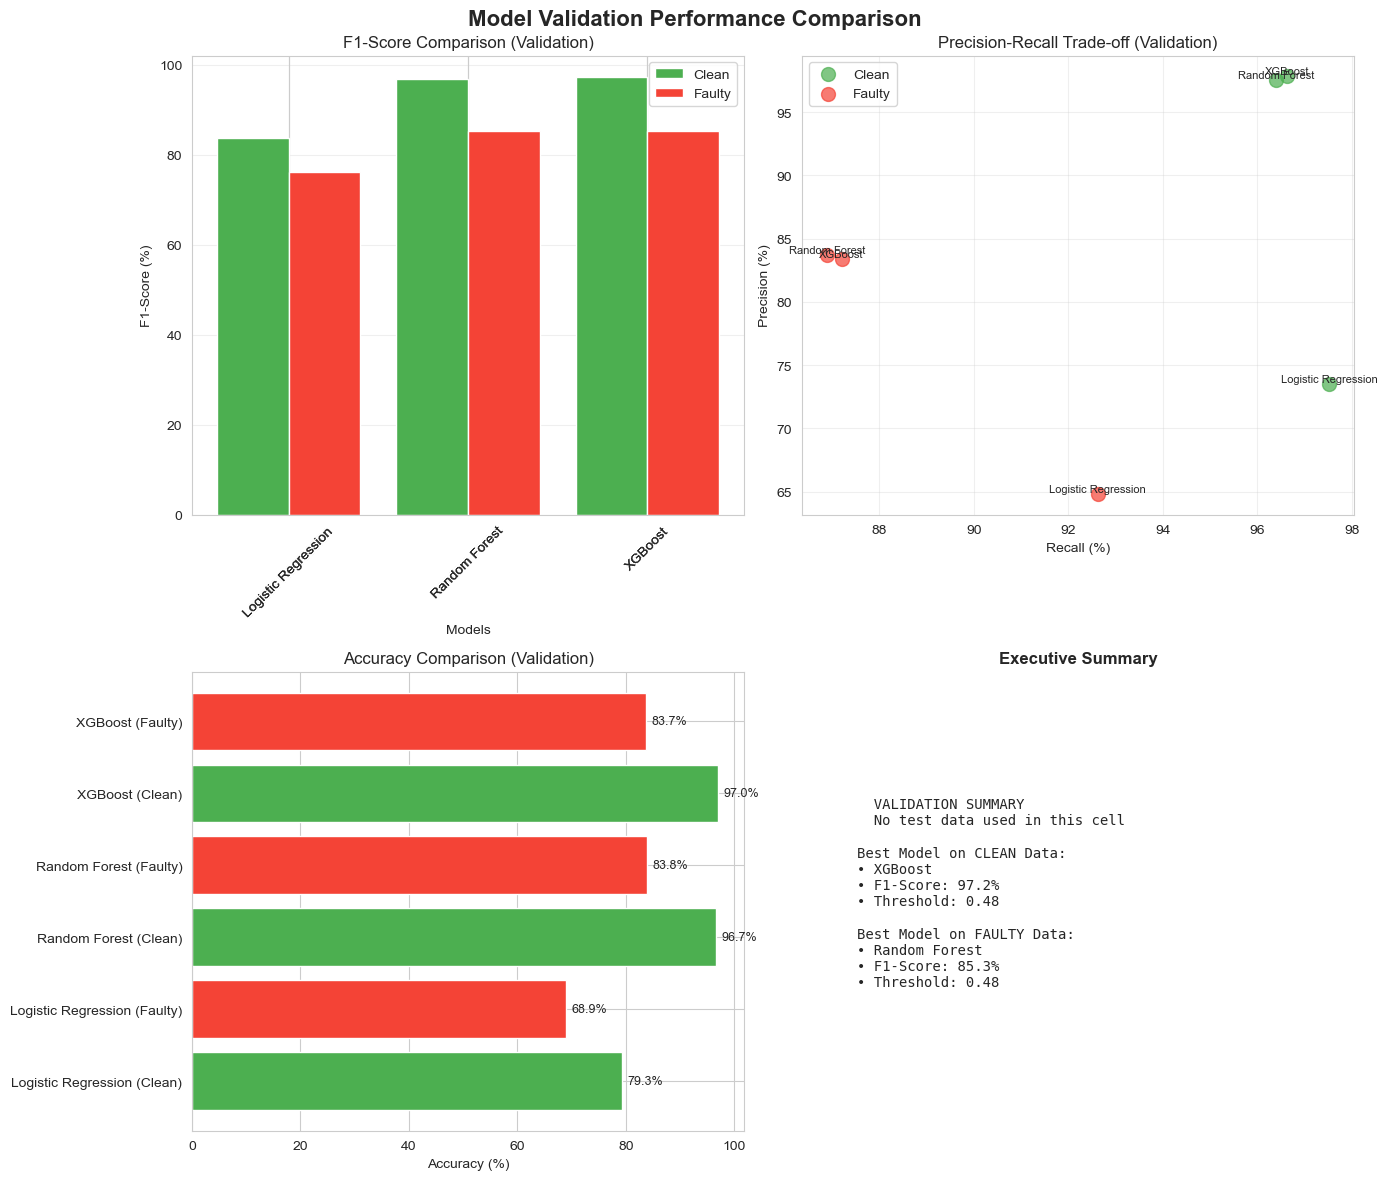

 Validation comparison saved as 'model_validation_comparison.png'

 Saving validation summary
 Validation summary saved to 'validation_summary.json'
 Validation Comparison Done


In [10]:
#FINAL MODEL COMPARISON

print(" FINAL MODEL COMPARISON (VALIDATION ONLY)")

print("\n Loading all model results")

results = {}

#Isolation Forest results
try:
    with open('isolation_forest_audit_results.json', 'r') as f:
        results['isolation_forest'] = json.load(f)
    print(" Isolation Forest results loaded")
except:
    print(" Isolation Forest results not found")
    results['isolation_forest'] = None

#logisitic regression
try:
    with open('logistic_regression_results.json', 'r') as f:
        results['logistic_regression'] = json.load(f)
    print(" Logistic Regression results loaded")
except:
    print(" Logistic Regression results not found")
    results['logistic_regression'] = None

# Random Forest results
try:
    with open('random_forest_results.json', 'r') as f:
        results['random_forest'] = json.load(f)
    print(" Random Forest results loaded")
except:
    print(" Random Forest results not found")
    results['random_forest'] = None

# XGBoost results
try:
    with open('xgboost_results.json', 'r') as f:
        results['xgboost'] = json.load(f)
    print(" XGBoost results loaded")
except:
    print(" XGBoost results not found")
    results['xgboost'] = None

if all(v is None for v in results.values()):
    print("\n No model results found! Please run CELLS 9-11 first.")
    raise FileNotFoundError("No model results found")

# VALIDATION COMPARISON TABLE

print(" MODEL VALIDATION PERFORMANCE COMPARISON")

comparison_data = []

# Isolation Forest (if available)
if results['isolation_forest'] is not None:
    if_results = results['isolation_forest']
    
    # Clean data metrics
    if 'clean' in if_results:
        comparison_data.append({
            'Model': 'Isolation Forest',
            'Dataset': 'Clean',
            'Type': 'Auditor',
            'ROC-AUC': if_results['clean'].get('roc_auc', 0),
            'PR-AUC': if_results['clean'].get('pr_auc', 0),
            'Anomaly Rate': if_results['clean'].get('anomaly_rate', 0),
            'Contamination': if_results['clean'].get('contamination_used', 0.01)
        })
    
    # Faulty data metrics
    if 'faulty' in if_results:
        comparison_data.append({
            'Model': 'Isolation Forest',
            'Dataset': 'Faulty',
            'Type': 'Auditor',
            'ROC-AUC': if_results['faulty'].get('roc_auc', 0),
            'PR-AUC': if_results['faulty'].get('pr_auc', 0),
            'Anomaly Rate': if_results['faulty'].get('anomaly_rate', 0),
            'Contamination': if_results['faulty'].get('contamination_used', 0.01)
        })
#Logistic regression
if results.get('logistic_regression') is not None:
    lr_results = results['logistic_regression']
    if 'clean' in lr_results and lr_results['clean'] is not None:
        val_metrics = lr_results['clean'].get('validation_metrics', {})
        if val_metrics:
            comparison_data.append({
                'Model': 'Logistic Regression', 'Dataset': 'Clean', 'Type': 'Supervised',
                'Accuracy': val_metrics.get('balanced', {}).get('accuracy', 0) * 100,
                'Precision': val_metrics.get('balanced', {}).get('precision', 0) * 100,
                'Recall': val_metrics.get('balanced', {}).get('recall', 0) * 100,
                'F1-Score': val_metrics.get('balanced', {}).get('f1', 0) * 100,
                'Threshold': val_metrics.get('balanced', {}).get('threshold', 0.5)
            })
    if 'faulty' in lr_results and lr_results['faulty'] is not None:
        val_metrics = lr_results['faulty'].get('validation_metrics', {})
        if val_metrics:
            comparison_data.append({
                'Model': 'Logistic Regression', 'Dataset': 'Faulty', 'Type': 'Supervised',
                'Accuracy': val_metrics.get('balanced', {}).get('accuracy', 0) * 100,
                'Precision': val_metrics.get('balanced', {}).get('precision', 0) * 100,
                'Recall': val_metrics.get('balanced', {}).get('recall', 0) * 100,
                'F1-Score': val_metrics.get('balanced', {}).get('f1', 0) * 100,
                'Threshold': val_metrics.get('balanced', {}).get('threshold', 0.5)
            })

# Random Forest (if available)
if results['random_forest'] is not None:
    rf_results = results['random_forest']
    
    # Clean data metrics (validation)
    if 'clean' in rf_results and rf_results['clean'] is not None:
        val_metrics = rf_results['clean'].get('validation_metrics', {})
        if val_metrics:
            comparison_data.append({
                'Model': 'Random Forest',
                'Dataset': 'Clean',
                'Type': 'Supervised',
                'Accuracy': val_metrics.get('balanced', {}).get('accuracy', 0) * 100,
                'Precision': val_metrics.get('balanced', {}).get('precision', 0) * 100,
                'Recall': val_metrics.get('balanced', {}).get('recall', 0) * 100,
                'F1-Score': val_metrics.get('balanced', {}).get('f1', 0) * 100,
                'Threshold': val_metrics.get('balanced', {}).get('threshold', 0.5)
            })
    
    # Faulty data metrics (validation)
    if 'faulty' in rf_results and rf_results['faulty'] is not None:
        val_metrics = rf_results['faulty'].get('validation_metrics', {})
        if val_metrics:
            comparison_data.append({
                'Model': 'Random Forest',
                'Dataset': 'Faulty',
                'Type': 'Supervised',
                'Accuracy': val_metrics.get('balanced', {}).get('accuracy', 0) * 100,
                'Precision': val_metrics.get('balanced', {}).get('precision', 0) * 100,
                'Recall': val_metrics.get('balanced', {}).get('recall', 0) * 100,
                'F1-Score': val_metrics.get('balanced', {}).get('f1', 0) * 100,
                'Threshold': val_metrics.get('balanced', {}).get('threshold', 0.5)
            })

# XGBoost (if available)
if results['xgboost'] is not None:
    xgb_results = results['xgboost']
    
    # Clean data metrics (validation)
    if 'clean' in xgb_results and xgb_results['clean'] is not None:
        val_metrics = xgb_results['clean'].get('validation_metrics', {})
        if val_metrics:
            comparison_data.append({
                'Model': 'XGBoost',
                'Dataset': 'Clean',
                'Type': 'Supervised',
                'Accuracy': val_metrics.get('balanced', {}).get('accuracy', 0) * 100,
                'Precision': val_metrics.get('balanced', {}).get('precision', 0) * 100,
                'Recall': val_metrics.get('balanced', {}).get('recall', 0) * 100,
                'F1-Score': val_metrics.get('balanced', {}).get('f1', 0) * 100,
                'Threshold': val_metrics.get('balanced', {}).get('threshold', 0.5)
            })
    
    # Faulty data metrics (validation)
    if 'faulty' in xgb_results and xgb_results['faulty'] is not None:
        val_metrics = xgb_results['faulty'].get('validation_metrics', {})
        if val_metrics:
            comparison_data.append({
                'Model': 'XGBoost',
                'Dataset': 'Faulty',
                'Type': 'Supervised',
                'Accuracy': val_metrics.get('balanced', {}).get('accuracy', 0) * 100,
                'Precision': val_metrics.get('balanced', {}).get('precision', 0) * 100,
                'Recall': val_metrics.get('balanced', {}).get('recall', 0) * 100,
                'F1-Score': val_metrics.get('balanced', {}).get('f1', 0) * 100,
                'Threshold': val_metrics.get('balanced', {}).get('threshold', 0.5)
            })

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)
if not comparison_df.empty:
    print(" VALIDATION PERFORMANCE MATRIX")
    print(comparison_df.to_string(index=False))
else:
    print("\n No comparison data available")
    

print("BEST MODEL SELECTION (Based on Validation F1-Score)")

best_clean = None
best_faulty = None

if not comparison_df.empty:
    # Best model on clean data
    clean_models = comparison_df[comparison_df['Dataset'] == 'Clean']
    if not clean_models.empty and 'F1-Score' in clean_models.columns:
        # Filter out rows without F1-Score (Isolation Forest)
        clean_with_f1 = clean_models[clean_models['F1-Score'].notna()]
        if not clean_with_f1.empty:
            best_clean_idx = clean_with_f1['F1-Score'].idxmax()
            best_clean = clean_with_f1.loc[best_clean_idx]
            
            print(f"\n  BEST MODEL ON CLEAN DATA:")
            print(f"   • Model: {best_clean['Model']}")
            print(f"   • F1-Score: {best_clean['F1-Score']:.2f}%")
            print(f"   • Accuracy: {best_clean['Accuracy']:.2f}%")
            print(f"   • Precision: {best_clean['Precision']:.2f}%")
            print(f"   • Recall: {best_clean['Recall']:.2f}%")
            print(f"   • Optimal Threshold: {best_clean['Threshold']:.2f}")
    
    # Best model on faulty data
    faulty_models = comparison_df[comparison_df['Dataset'] == 'Faulty']
    if not faulty_models.empty and 'F1-Score' in faulty_models.columns:
        # Filter out rows without F1-Score (Isolation Forest)
        faulty_with_f1 = faulty_models[faulty_models['F1-Score'].notna()]
        if not faulty_with_f1.empty:
            best_faulty_idx = faulty_with_f1['F1-Score'].idxmax()
            best_faulty = faulty_with_f1.loc[best_faulty_idx]
            
            print(f"\n  BEST MODEL ON FAULTY DATA:")
            print(f"   • Model: {best_faulty['Model']}")
            print(f"   • F1-Score: {best_faulty['F1-Score']:.2f}%")
            print(f"   • Accuracy: {best_faulty['Accuracy']:.2f}%")
            print(f"   • Precision: {best_faulty['Precision']:.2f}%")
            print(f"   • Recall: {best_faulty['Recall']:.2f}%")
            print(f"   • Optimal Threshold: {best_faulty['Threshold']:.2f}")

#VARIABLES FOR SUMMARY TEXT

# Clean data summary
best_clean_model = best_clean['Model'] if best_clean is not None else 'N/A'
best_clean_f1 = f"{best_clean['F1-Score']:.1f}%" if best_clean is not None else 'N/A'
best_clean_threshold = f"{best_clean['Threshold']:.2f}" if best_clean is not None else 'N/A'

# Faulty data summary
best_faulty_model = best_faulty['Model'] if best_faulty is not None else 'N/A'
best_faulty_f1 = f"{best_faulty['F1-Score']:.1f}%" if best_faulty is not None else 'N/A'
best_faulty_threshold = f"{best_faulty['Threshold']:.2f}" if best_faulty is not None else 'N/A'

# VISUALIZATIONS

print("\n Generating validation comparison visualizations")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Model Validation Performance Comparison', fontsize=16, fontweight='bold')

# F1-Score Comparison
ax1 = axes[0, 0]
if not comparison_df.empty and 'F1-Score' in comparison_df.columns:
    clean_f1_data = comparison_df[(comparison_df['Dataset'] == 'Clean') & 
                                   (comparison_df['F1-Score'].notna())]
    faulty_f1_data = comparison_df[(comparison_df['Dataset'] == 'Faulty') & 
                                    (comparison_df['F1-Score'].notna())]
    
    models_clean = clean_f1_data['Model'].tolist()
    models_faulty = faulty_f1_data['Model'].tolist()
    
    clean_f1 = clean_f1_data['F1-Score'].tolist()
    faulty_f1 = faulty_f1_data['F1-Score'].tolist()
    
    x_clean = np.arange(len(models_clean)) if len(models_clean) > 0 else []
    x_faulty = np.arange(len(models_faulty)) if len(models_faulty) > 0 else []
    
    if len(x_clean) > 0:
        ax1.bar(x_clean - 0.2, clean_f1, 0.4, label='Clean', color='#4CAF50')
    if len(x_faulty) > 0:
        ax1.bar(x_faulty + 0.2, faulty_f1, 0.4, label='Faulty', color='#F44336')
    
    # Safe xtick setting
    all_positions = list(x_clean) + list(x_faulty)
    all_labels = models_clean + models_faulty
    if len(all_positions) > 0:
        ax1.set_xticks(all_positions)
        ax1.set_xticklabels(all_labels, rotation=45)
    
    ax1.set_xlabel('Models')
    ax1.set_ylabel('F1-Score (%)')
    ax1.set_title('F1-Score Comparison (Validation)')
    ax1.grid(axis='y', alpha=0.3)
if len(all_positions) > 0:
    ax1.legend()
#Precision-Recall Trade-off
ax2 = axes[0, 1]
if not comparison_df.empty and 'Precision' in comparison_df.columns and 'Recall' in comparison_df.columns:
    for dataset in ['Clean', 'Faulty']:
        subset = comparison_df[(comparison_df['Dataset'] == dataset) & 
                               (comparison_df['Precision'].notna())]
        if not subset.empty:
            ax2.scatter(subset['Recall'], subset['Precision'], 
                       label=dataset, s=100, alpha=0.7,
                       c=['#4CAF50' if dataset == 'Clean' else '#F44336'])
            
            # Annotate points
            for _, row in subset.iterrows():
                ax2.annotate(row['Model'], 
                           (row['Recall'], row['Precision']),
                           fontsize=8, ha='center', va='bottom')
    
    ax2.set_xlabel('Recall (%)')
    ax2.set_ylabel('Precision (%)')
    ax2.set_title('Precision-Recall Trade-off (Validation)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

#Accuracy Comparison
ax3 = axes[1, 0]
if not comparison_df.empty and 'Accuracy' in comparison_df.columns:
    # Filter out rows without Accuracy (Isolation Forest)
    acc_data = comparison_df[comparison_df['Accuracy'].notna()]
    if not acc_data.empty:
        models = acc_data['Model'] + ' (' + acc_data['Dataset'] + ')'
        accuracies = acc_data['Accuracy']
        colors = ['#4CAF50' if d == 'Clean' else '#F44336' for d in acc_data['Dataset']]
        
        bars = ax3.barh(models, accuracies, color=colors)
        ax3.set_xlabel('Accuracy (%)')
        ax3.set_title('Accuracy Comparison (Validation)')
        
        for bar, acc in zip(bars, accuracies):
            ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{acc:.1f}%', va='center', fontsize=9)

# 4. Summary Text
ax4 = axes[1, 1]
ax4.axis('off')

summary_text = f"""
  VALIDATION SUMMARY
  No test data used in this cell

Best Model on CLEAN Data:
• {best_clean_model}
• F1-Score: {best_clean_f1}
• Threshold: {best_clean_threshold}

Best Model on FAULTY Data:
• {best_faulty_model}
• F1-Score: {best_faulty_f1}
• Threshold: {best_faulty_threshold}

"""

ax4.text(0.1, 0.5, summary_text, fontsize=10, va='center', fontfamily='monospace')
ax4.set_title('Executive Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('model_validation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Validation comparison saved as 'model_validation_comparison.png'")

# VALIDATION SUMMARY

print("\n Saving validation summary")

validation_summary = {
    'comparison_table': comparison_df.to_dict(orient='records') if not comparison_df.empty else [],
    'best_model_clean': {
        'model': best_clean['Model'] if best_clean is not None else None,
        'metrics': best_clean.to_dict() if best_clean is not None else None
    } if best_clean is not None else None,
    'best_model_faulty': {
        'model': best_faulty['Model'] if best_faulty is not None else None,
        'metrics': best_faulty.to_dict() if best_faulty is not None else None
    } if best_faulty is not None else None,
    'note': 'Validation only - No test data used in this cell'
}

with open('validation_summary.json', 'w') as f:
    json.dump(validation_summary, f, indent=2)

print(" Validation summary saved to 'validation_summary.json'")

print(" Validation Comparison Done")

 FINAL TEST EVALUATION
 Test data used for the FIRST and ONLY time
 Final performance metrics for publication
 Model comparison on unseen data
 Threshold Sensitivity Analysis
 Robustness Score Calculation

 Loading test data
 Clean test data loaded successfully
   • Test samples: 175,341
   • Features: 15
   • Class distribution: [ 56000 119341]
 Faulty test data loaded successfully
   • Test samples: 175,341
   • Features: 15
   • Class distribution: [ 56000 119341]

 Loading models and optimal thresholds
 Random Forest model loaded
   • Optimal thresholds: {'balanced_grid': 0.4755102040816327, 'security': 0.1, 'operations': 0.9}
 XGBoost model loaded
   • Optimal thresholds: {'balanced_grid': 0.4755102040816327, 'security': 0.1, 'operations': 0.9}
 Logistic Regression model loaded
   • Optimal thresholds: {'balanced_grid': 0.263265306122449, 'security': 0.1, 'operations': 0.9}
 TESTING ON CLEAN DATA
 EVALUATING RANDOM FOREST (CLEAN TEST) ON TEST DATA
   • ROC-AUC: 0.9858 (threshold i

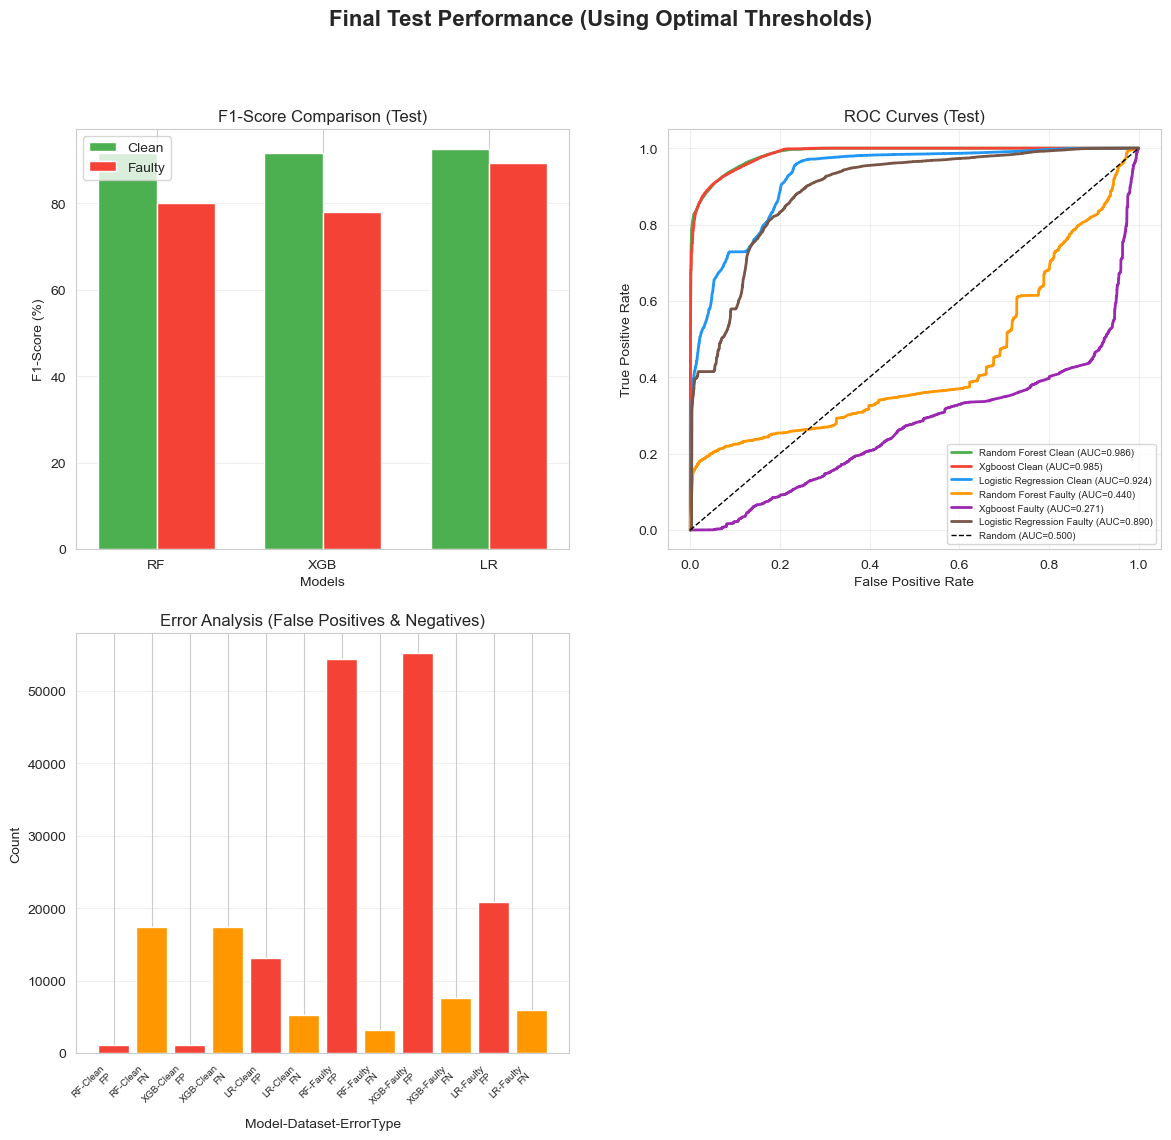

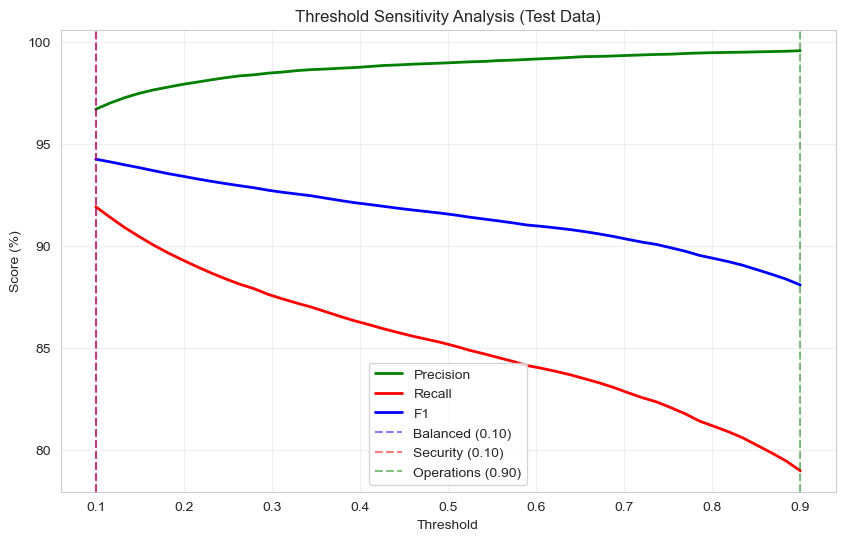

 Threshold sensitivity plot saved as 'threshold_sensitivity_test.png'
 ROBUSTNESS SCORE
Purpose: Single metric quantifying model resilience to data quality issues
 Score = (Faulty F1 / Clean F1) × 100
 Higher = More robust

  RF ROBUSTNESS SCORE:
   • Clean F1:    91.68%
   • Faulty F1:   80.13%
   • Retention:   87.4%
   • SCORE:       87.4/100
    FAIR - Some degradation, but acceptable

  XGB ROBUSTNESS SCORE:
   • Clean F1:    91.69%
   • Faulty F1:   78.04%
   • Retention:   85.1%
   • SCORE:       85.1/100
    FAIR - Some degradation, but acceptable

  LR ROBUSTNESS SCORE:
   • Clean F1:    92.53%
   • Faulty F1:   89.42%
   • Retention:   96.6%
   • SCORE:       96.6/100
    EXCELLENT - Model highly robust to data quality issues

 OVERALL FRAMEWORK ROBUSTNESS: 89.7/100
 PRIMARY MODEL (LR) ROBUSTNESS: 96.6/100
 Robustness report saved to 'robustness_report.json'

 UPDATED COMPARISON TABLE WITH ROBUSTNESS:
Model Dataset  Threshold  Accuracy  Precision    Recall        F1  ROC-AUC 

<Figure size 800x600 with 0 Axes>

 Test results visualization saved as 'final_test_results.png'

 Saving final test results
  Final results saved to 'final_test_results.json'
 Final Test Evaluation Done


In [22]:
print(" FINAL TEST EVALUATION")
print(" Test data used for the FIRST and ONLY time")
print(" Final performance metrics for publication")
print(" Model comparison on unseen data")
print(" Threshold Sensitivity Analysis")
print(" Robustness Score Calculation")


print("\n Loading test data")

try:
    X_test_clean, y_test_clean = joblib.load('clean_supervised_test.pkl')
    print(" Clean test data loaded successfully")
    print(f"   • Test samples: {X_test_clean.shape[0]:,}")
    print(f"   • Features: {X_test_clean.shape[1]}")
    print(f"   • Class distribution: {np.bincount(y_test_clean)}")
except:
    print(" Could not load clean test data")
    X_test_clean, y_test_clean = None, None

try:
    X_test_faulty, y_test_faulty = joblib.load('faulty_supervised_test.pkl')
    print(" Faulty test data loaded successfully")
    print(f"   • Test samples: {X_test_faulty.shape[0]:,}")
    print(f"   • Features: {X_test_faulty.shape[1]}")
    print(f"   • Class distribution: {np.bincount(y_test_faulty)}")
except:
    print(" Faulty test data not found")
    X_test_faulty, y_test_faulty = None, None

if X_test_clean is None and X_test_faulty is None:
    print("\n No test data found! Cannot proceed.")
    raise FileNotFoundError("No test data found")

print("\n Loading models and optimal thresholds")

models = {}
thresholds = {}

# Load Random Forest
try:
    models['random_forest'] = joblib.load('random_forest_clean.pkl')
    print(" Random Forest model loaded")
    with open('random_forest_thresholds.json', 'r') as f:
        rf_thresholds = json.load(f)
        if rf_thresholds.get('clean') and rf_thresholds['clean'].get('optimal_thresholds'):
            thresholds['random_forest'] = rf_thresholds['clean']['optimal_thresholds']
            print(f"   • Optimal thresholds: {thresholds['random_forest']}")
except:
    print(" Random Forest model or thresholds not found")
    models['random_forest'] = None
    thresholds['random_forest'] = None

# Load XGBoost
try:
    models['xgboost'] = joblib.load('xgboost_clean.pkl')
    print(" XGBoost model loaded")
    with open('xgboost_thresholds.json', 'r') as f:
        xgb_thresholds = json.load(f)
        if xgb_thresholds.get('clean') and xgb_thresholds['clean'].get('optimal_thresholds'):
            thresholds['xgboost'] = xgb_thresholds['clean']['optimal_thresholds']
            print(f"   • Optimal thresholds: {thresholds['xgboost']}")
except:
    print(" XGBoost model or thresholds not found")
    models['xgboost'] = None
    thresholds['xgboost'] = None

# Load Logistic Regression
try:
    models['logistic_regression'] = joblib.load('logistic_regression_clean.pkl')
    print(" Logistic Regression model loaded")
    with open('logistic_regression_thresholds.json', 'r') as f:
        lr_thresholds = json.load(f)
        if lr_thresholds.get('clean') and lr_thresholds['clean'].get('optimal_thresholds'):
            thresholds['logistic_regression'] = lr_thresholds['clean']['optimal_thresholds']
            print(f"   • Optimal thresholds: {thresholds['logistic_regression']}")
except:
    print(" Logistic Regression model or thresholds not found")
    models['logistic_regression'] = None
    thresholds['logistic_regression'] = None

# FUNCTION TO EVALUATE MODEL ON TEST DATA

def evaluate_on_test(model, X_test, y_test, model_name, threshold_dict):
    if model is None or X_test is None:
        return None, None

    print(f" EVALUATING {model_name.upper()} ON TEST DATA")

    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"   • ROC-AUC: {roc_auc:.4f} (threshold independent)")

    results = {}
    scenarios = [
        ('balanced', threshold_dict.get('balanced_grid', 0.5) if threshold_dict else 0.5),
        ('security', threshold_dict.get('security', 0.3) if threshold_dict else 0.3),
        ('operations', threshold_dict.get('operations', 0.7) if threshold_dict else 0.7),
        ('default', 0.5)
    ]

    for scenario_name, threshold in scenarios:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results[scenario_name] = {
            'threshold': threshold,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'roc_auc': roc_auc,
            'confusion_matrix': {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)},
            'false_positive_rate': fp / (fp + tn) if (fp + tn) > 0 else 0,
            'false_negative_rate': fn / (fn + tp) if (fn + tp) > 0 else 0
        }

        print(f"\n {scenario_name.upper()} SCENARIO (thresh={threshold:.3f}):")
        print(f"   • Accuracy:  {results[scenario_name]['accuracy']*100:.2f}%")
        print(f"   • Precision: {results[scenario_name]['precision']*100:.2f}%")
        print(f"   • Recall:    {results[scenario_name]['recall']*100:.2f}%")
        print(f"   • F1-Score:  {results[scenario_name]['f1']*100:.2f}%")
        print(f"   • False Positives: {fp:,} | False Negatives: {fn:,}")

    return results, y_proba

# EVALUATE ON CLEAN TEST DATA

test_results = {}
roc_data = {}

if X_test_clean is not None:
    print(" TESTING ON CLEAN DATA")

    for key, label in [('random_forest', 'Random Forest'), ('xgboost', 'XGBoost'), ('logistic_regression', 'Logistic Regression')]:
        if models[key] is not None:
            res, proba = evaluate_on_test(models[key], X_test_clean, y_test_clean, f'{label} (Clean Test)', thresholds.get(key))
            test_results[f'{key}_clean'] = res
            roc_data[f'{key}_clean'] = {'y_test': y_test_clean, 'y_proba': proba, 'roc_auc': res['balanced']['roc_auc'] if res else None}

# EVALUATE ON FAULTY TEST DATA

if X_test_faulty is not None:
    print(" TESTING ON FAULTY DATA")

    for key, label in [('random_forest', 'Random Forest'), ('xgboost', 'XGBoost'), ('logistic_regression', 'Logistic Regression')]:
        if models[key] is not None:
            res, proba = evaluate_on_test(models[key], X_test_faulty, y_test_faulty, f'{label} (Faulty Test)', thresholds.get(key))
            test_results[f'{key}_faulty'] = res
            roc_data[f'{key}_faulty'] = {'y_test': y_test_faulty, 'y_proba': proba, 'roc_auc': res['balanced']['roc_auc'] if res else None}

# FINAL COMPARISON 

print(" FINAL TEST PERFORMANCE COMPARISON")

comparison_data = []
acc_drop_rf = acc_drop_xgb = acc_drop_lr = None
f1_drop_rf = f1_drop_xgb = f1_drop_lr = None

MODEL_LABELS = {'random_forest': 'RF', 'xgboost': 'XGB', 'logistic_regression': 'LR'}

for result_key, result_value in test_results.items():
    if result_value and 'balanced' in result_value:
        base_key = next(k for k in MODEL_LABELS if result_key.startswith(k))
        model_name = MODEL_LABELS[base_key]
        dataset = 'Clean' if 'clean' in result_key else 'Faulty'

        comp = {
            'Model': model_name,
            'Dataset': dataset,
            'Threshold': result_value['balanced']['threshold'],
            'Accuracy': result_value['balanced']['accuracy'] * 100,
            'Precision': result_value['balanced']['precision'] * 100,
            'Recall': result_value['balanced']['recall'] * 100,
            'F1': result_value['balanced']['f1'] * 100,
            'ROC-AUC': result_value['balanced']['roc_auc'],
            'FP': result_value['balanced']['confusion_matrix']['fp'],
            'FN': result_value['balanced']['confusion_matrix']['fn']
        }
        comparison_data.append(comp)

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + comparison_df.to_string(index=False))

    print(" PERFORMANCE DUE TO FAULTY DATA")

    for model in ['RF', 'XGB', 'LR']:
        clean_row = comparison_df[(comparison_df['Model'] == model) & (comparison_df['Dataset'] == 'Clean')]
        faulty_row = comparison_df[(comparison_df['Model'] == model) & (comparison_df['Dataset'] == 'Faulty')]

        if not clean_row.empty and not faulty_row.empty:
            acc_drop = clean_row['Accuracy'].values[0] - faulty_row['Accuracy'].values[0]
            f1_drop = clean_row['F1'].values[0] - faulty_row['F1'].values[0]

            if model == 'RF':   acc_drop_rf, f1_drop_rf = acc_drop, f1_drop
            elif model == 'XGB': acc_drop_xgb, f1_drop_xgb = acc_drop, f1_drop
            else:                acc_drop_lr, f1_drop_lr = acc_drop, f1_drop

            print(f"\n{model}:")
            print(f"   • Accuracy Drop: {acc_drop:.2f}%")
            print(f"   • F1-Score Drop: {f1_drop:.2f}%")
else:
    print("\n No test results available")

# VISUALIZE

print("\n Generating test result visualizations")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Final Test Performance (Using Optimal Thresholds)', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
if comparison_data:
    models_list = comparison_df['Model'].unique()
    x = np.arange(len(models_list))
    width = 0.35

    clean_f1, faulty_f1 = [], []
    for model in models_list:
        clean_val = comparison_df[(comparison_df['Model'] == model) & (comparison_df['Dataset'] == 'Clean')]['F1'].values
        faulty_val = comparison_df[(comparison_df['Model'] == model) & (comparison_df['Dataset'] == 'Faulty')]['F1'].values
        clean_f1.append(clean_val[0] if len(clean_val) > 0 else 0)
        faulty_f1.append(faulty_val[0] if len(faulty_val) > 0 else 0)

    ax1.bar(x - width/2, clean_f1, width, label='Clean', color='#4CAF50')
    ax1.bar(x + width/2, faulty_f1, width, label='Faulty', color='#F44336')
    ax1.set_xlabel('Models'); ax1.set_ylabel('F1-Score (%)')
    ax1.set_title('F1-Score Comparison (Test)')
    ax1.set_xticks(x); ax1.set_xticklabels(models_list)
    ax1.legend(); ax1.grid(axis='y', alpha=0.3)


ax2 = axes[0, 1]
colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800', '#9C27B0', '#795548']
color_idx = 0
for key, data in roc_data.items():
    if data['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(data['y_test'], data['y_proba'])
        label = key.replace('_', ' ').title()
        ax2.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={data['roc_auc']:.3f})", color=colors[color_idx % len(colors)])
        color_idx += 1
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves (Test)')
ax2.legend(fontsize=7, loc='lower right'); ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
if comparison_data:
    error_data, error_labels = [], []
    for _, row in comparison_df.iterrows():
        error_data.append(row['FP']); error_data.append(row['FN'])
        error_labels.append(f"{row['Model']}-{row['Dataset']}\nFP")
        error_labels.append(f"{row['Model']}-{row['Dataset']}\nFN")
    x = np.arange(len(error_labels))
    colors_error = ['#F44336' if 'FP' in label else '#FF9800' for label in error_labels]
    ax3.bar(x, error_data, color=colors_error)
    ax3.set_xlabel('Model-Dataset-ErrorType'); ax3.set_ylabel('Count')
    ax3.set_title('Error Analysis (False Positives & Negatives)')
    ax3.set_xticks(x); ax3.set_xticklabels(error_labels, rotation=45, ha='right', fontsize=7)
    ax3.grid(axis='y', alpha=0.3)


ax4 = axes[1, 1]
ax4.axis('off')

if comparison_data:
    clean_only = comparison_df[comparison_df['Dataset'] == 'Clean']
    if not clean_only.empty:
        best_clean_idx = clean_only['F1'].idxmax()
        best_clean_model = clean_only.loc[best_clean_idx]['Model']
        best_clean_f1 = clean_only.loc[best_clean_idx]['F1']
    else:
        best_clean_model, best_clean_f1 = 'N/A', 0

    faulty_only = comparison_df[comparison_df['Dataset'] == 'Faulty']
    if not faulty_only.empty:
        best_faulty_idx = faulty_only['F1'].idxmax()
        best_faulty_model = faulty_only.loc[best_faulty_idx]['Model']
        best_faulty_f1 = faulty_only.loc[best_faulty_idx]['F1']
    else:
        best_faulty_model, best_faulty_f1 = 'N/A', 0
else:
    best_clean_model, best_clean_f1 = 'N/A', 0
    best_faulty_model, best_faulty_f1 = 'N/A', 0

rf_drop_str  = f"{acc_drop_rf:.2f}%"  if acc_drop_rf  is not None else 'N/A'
xgb_drop_str = f"{acc_drop_xgb:.2f}%" if acc_drop_xgb is not None else 'N/A'
lr_drop_str  = f"{acc_drop_lr:.2f}%"  if acc_drop_lr  is not None else 'N/A'


print(" THRESHOLD SENSITIVITY ANALYSIS")
print("Shows optimal operating points for different scenarios")
print("Security (max recall) vs Operations (max precision)")

best_model = models['xgboost'] if models['xgboost'] else (models['random_forest'] if models['random_forest'] else models['logistic_regression'])
if best_model is not None and X_test_clean is not None:
    y_proba = best_model.predict_proba(X_test_clean)[:, 1]

    thresholds_sweep = np.linspace(0.1, 0.9, 50)
    sens_results = []
    for t in thresholds_sweep:
        y_pred = (y_proba >= t).astype(int)
        sens_results.append({'Threshold': t, 'Precision': precision_score(y_test_clean, y_pred), 'Recall': recall_score(y_test_clean, y_pred), 'F1': f1_score(y_test_clean, y_pred)})

    sens_df = pd.DataFrame(sens_results)
    best_f1 = sens_df.loc[sens_df['F1'].idxmax()]
    best_recall = sens_df.loc[sens_df['Recall'].idxmax()]
    best_precision = sens_df.loc[sens_df['Precision'].idxmax()]

    print(f"\n OPTIMAL THRESHOLDS (TEST DATA):")
    print(f"   • Balanced (F1):        {best_f1['Threshold']:.2f} (F1={best_f1['F1']*100:.1f}%)")
    print(f"   • Security (Max Recall): {best_recall['Threshold']:.2f} (Recall={best_recall['Recall']*100:.1f}%)")
    print(f"   • Operations (Max Prec): {best_precision['Threshold']:.2f} (Prec={best_precision['Precision']*100:.1f}%)")

    plt.figure(figsize=(10,6))
    plt.plot(sens_df['Threshold'], sens_df['Precision']*100, 'g-', label='Precision', linewidth=2)
    plt.plot(sens_df['Threshold'], sens_df['Recall']*100, 'r-', label='Recall', linewidth=2)
    plt.plot(sens_df['Threshold'], sens_df['F1']*100, 'b-', label='F1', linewidth=2)
    plt.axvline(x=best_f1['Threshold'], color='blue', linestyle='--', alpha=0.5, label=f'Balanced ({best_f1["Threshold"]:.2f})')
    plt.axvline(x=best_recall['Threshold'], color='red', linestyle='--', alpha=0.5, label=f'Security ({best_recall["Threshold"]:.2f})')
    plt.axvline(x=best_precision['Threshold'], color='green', linestyle='--', alpha=0.5, label=f'Operations ({best_precision["Threshold"]:.2f})')
    plt.xlabel('Threshold'); plt.ylabel('Score (%)')
    plt.title('Threshold Sensitivity Analysis (Test Data)')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig('threshold_sensitivity_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Threshold sensitivity plot saved as 'threshold_sensitivity_test.png'")
else:
    print("\n Cannot perform threshold analysis - missing model or test data")
    best_f1 = {'Threshold': 0.5, 'F1': 0}
    best_recall = {'Threshold': 0.1, 'Recall': 0}
    best_precision = {'Threshold': 0.9, 'Precision': 0}

# ROBUSTNESS SCORE CALCULATION

print(" ROBUSTNESS SCORE")
print("Purpose: Single metric quantifying model resilience to data quality issues")
print(" Score = (Faulty F1 / Clean F1) × 100")
print(" Higher = More robust")

if 'comparison_df' not in locals() or comparison_df.empty:
    print("  Cannot calculate robustness score - comparison data missing")
    robustness_scores = {}
    avg_robustness = 0
    primary_robustness = 0
    primary_model = "N/A"
else:
    robustness_scores = {}

    for model in ['RF', 'XGB', 'LR']:
        clean_row = comparison_df[(comparison_df['Model'] == model) & (comparison_df['Dataset'] == 'Clean')]
        faulty_row = comparison_df[(comparison_df['Model'] == model) & (comparison_df['Dataset'] == 'Faulty')]

        if not clean_row.empty and not faulty_row.empty:
            clean_f1 = clean_row['F1'].values[0]
            faulty_f1 = faulty_row['F1'].values[0]
            robustness = (faulty_f1 / clean_f1) * 100
            robustness_scores[model] = robustness

            print(f"\n  {model} ROBUSTNESS SCORE:")
            print(f"   • Clean F1:    {clean_f1:.2f}%")
            print(f"   • Faulty F1:   {faulty_f1:.2f}%")
            print(f"   • Retention:   {(faulty_f1/clean_f1)*100:.1f}%")
            print(f"   • SCORE:       {robustness:.1f}/100")

            if robustness >= 95:   print(f"    EXCELLENT - Model highly robust to data quality issues")
            elif robustness >= 90: print(f"    GOOD - Model handles data issues well")
            elif robustness >= 85: print(f"    FAIR - Some degradation, but acceptable")
            else:                  print(f"    POOR - Model sensitive to data quality")

    if len(robustness_scores) > 0:
        avg_robustness = np.mean(list(robustness_scores.values()))
        primary_model = max(robustness_scores, key=robustness_scores.get)
        primary_robustness = robustness_scores[primary_model]

        print(f"\n OVERALL FRAMEWORK ROBUSTNESS: {avg_robustness:.1f}/100")
        print(f" PRIMARY MODEL ({primary_model}) ROBUSTNESS: {primary_robustness:.1f}/100")
    else:
        avg_robustness = 0
        primary_robustness = 0
        primary_model = "N/A"

robustness_report = {
    "robustness_scores": {k: float(v) for k, v in robustness_scores.items()},
    "overall_framework": float(avg_robustness),
    "primary_model": str(primary_model),
    "primary_score": float(primary_robustness) if primary_robustness else None,
    "calculation": "(Faulty F1 / Clean F1) × 100",
    "interpretation": ">95=Excellent, >90=Good, >85=Fair, <85=Poor"
}

with open('robustness_report.json', 'w') as f:
    json.dump(robustness_report, f, indent=2)
print(" Robustness report saved to 'robustness_report.json'")

if 'comparison_df' in locals() and not comparison_df.empty and robustness_scores:
    comparison_df['Robustness'] = comparison_df['Model'].map(robustness_scores)
    print("\n UPDATED COMPARISON TABLE WITH ROBUSTNESS:")
    print(comparison_df.to_string(index=False))

# FINAL SUMMARY

avg_robustness = np.mean(list(robustness_scores.values())) if len(robustness_scores) > 0 else 0

summary_text = f"""
  FINAL TEST RESULTS
  Test data used for FIRST time
  Optimal thresholds from validation

Best Model on CLEAN:
• {best_clean_model}
• F1-Score: {best_clean_f1:.2f}%

Best Model on FAULTY:
• {best_faulty_model}
• F1-Score: {best_faulty_f1:.2f}%

Impact of Data Quality:
• RF Accuracy Drop:  {rf_drop_str}
• XGB Accuracy Drop: {xgb_drop_str}
• LR Accuracy Drop:  {lr_drop_str}

  ROBUSTNESS SCORES:
• RF:  {robustness_scores.get('RF', 0):.1f}/100
• XGB: {robustness_scores.get('XGB', 0):.1f}/100
• LR:  {robustness_scores.get('LR', 0):.1f}/100
• OVERALL: {avg_robustness:.1f}/100

  OPTIMAL THRESHOLDS:
• Balanced (F1): {best_f1['Threshold']:.2f} (F1={best_f1['F1']*100:.1f}%)
• Security (Max Recall): {best_recall['Threshold']:.2f} (Recall={best_recall['Recall']*100:.1f}%)
• Operations (Max Prec): {best_precision['Threshold']:.2f} (Prec={best_precision['Precision']*100:.1f}%)

"""

ax4.text(0.1, 0.5, summary_text, fontsize=8, va='center', fontfamily='monospace')

plt.tight_layout()
plt.savefig('final_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Test results visualization saved as 'final_test_results.png'")

# SAVE FINAL RESULTS (JSON-SAFE VERSION)

print("\n Saving final test results")

json_safe_results = {}
for key, value in test_results.items():
    if value is not None:
        json_safe_results[key] = {}
        for scenario, metrics in value.items():
            json_safe_results[key][scenario] = {k: v for k, v in metrics.items() if k != 'y_proba'}

final_results = {
    'test_results': json_safe_results,
    'comparison_table': comparison_data,
    'performance_drops': {
        'rf_accuracy_drop': float(acc_drop_rf) if acc_drop_rf is not None else None,
        'xgboost_accuracy_drop': float(acc_drop_xgb) if acc_drop_xgb is not None else None,
        'lr_accuracy_drop': float(acc_drop_lr) if acc_drop_lr is not None else None
    },
    'robustness_scores': {k: float(v) for k, v in robustness_scores.items()},
    'optimal_thresholds_test': {
        'balanced': float(best_f1['Threshold']),
        'security': float(best_recall['Threshold']),
        'operations': float(best_precision['Threshold'])
    },
    'best_model_clean': {'model': best_clean_model, 'f1': float(best_clean_f1)} if best_clean_model != 'N/A' else None,
    'best_model_faulty': {'model': best_faulty_model, 'f1': float(best_faulty_f1)} if best_faulty_model != 'N/A' else None,
    'note': 'Final evaluation on test data with optimal thresholds from validation'
}

with open('final_test_results.json', 'w') as f:
    json.dump(final_results, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.floating, np.integer)) else x)

print("  Final results saved to 'final_test_results.json'")

print(" Final Test Evaluation Done")
